**A PU-aware ranking pipeline for [Detect Suspicious Value Transfers in Poker](https://www.kaggle.com/competitions/detect-suspicious-value-transfers-in-poker)**

| Public LB (best) | Method snapshot | Train pairs |
|---|---|---|
| **0.64469** | 24k PU negatives (weight 0.35) + partner-vs-field + family OvR blend + evidence ranker | 25,860 (372 pos / 1,488 confirmed-neg / 24,000 PU) |

This notebook is a full write-up of the method: why the labels are positive-unlabeled, what the planted collusion families look like, how pair features are built from raw actions, and which experiments actually moved the public score.

**Score to beat in context.** The public starter sits near logistic chip-flow. A strong public notebook ([Nomannic](https://www.kaggle.com/code/nomannic19/poker-collusion-pu-aware-evidence-ranker)) scores **0.55758**. Private top is **~0.93**. The gap from 0.64 to 0.90 is not “a better booster”; it is matching the synthetic generator’s hand templates.

---

### Contents

1. [Problem, metric, and why 0.97 OOF is a trap](#1)
2. [Data model and EDA](#2)
3. [Positive-unlabeled sampling](#3)
4. [System architecture](#4)
5. [Feature philosophy by family](#5)
6. [Models: pair risk, family, evidence](#6)
7. [Public ablation](#7)
8. [Runnable pipeline](#8)
9. [What is still on the table](#9)


<a id="1"></a>
## 1. Problem, metric, and why 0.97 OOF is a trap

The dataset is **synthetic 6-max NLHE**: ~2M hands, 12k players, **400 pools of 30** that never mix (`table_id`). Time is split 60/40 into `development` / `evaluation` on `hands.phase`.

You submit one row per **evaluation pair** (112,540 rows):

| Column | Role |
|---|---|
| `risk_score` | \(0\)–\(1\), higher = more likely collusion (**70%** of the score via Pair AP) |
| `predicted_behavior` | `none` or one of three disclosed families (**10%**, macro OvR AP). `other_coordination` is legal but **excluded from Behavior MAP** — we never predict it |
| `evidence_hand_1..5` | evaluation-period hands containing both players, or `NO_EVIDENCE` (**20%**, MAP@5) |

\[
\text{Score} = 0.70\cdot \text{PairAP} + 0.20\cdot \text{MAP@5} + 0.10\cdot \text{BehaviorMAP}
\]

**Labels are PU, not PN.** `development_labels.csv` has 1,860 confirmed pairs (372 positive, 1,488 negative). Every unlisted co-seated pair is **unlabeled**, not negative. Training only on 1,860 makes labeled OOF AP look like 0.93–0.97 while public Pair AP collapses: the model never saw “ordinary” pairs that dominate the 112k eval list.

We therefore track two numbers:

- **Labeled AP** — 372 vs 1,488. Easy. Ignore for model selection.
- **PU-stress AP** — treat 24k unlabeled as negatives, reweight them by `n_eval / n_PU`. This tracked public LB (~0.617 OOF vs 0.645 public).


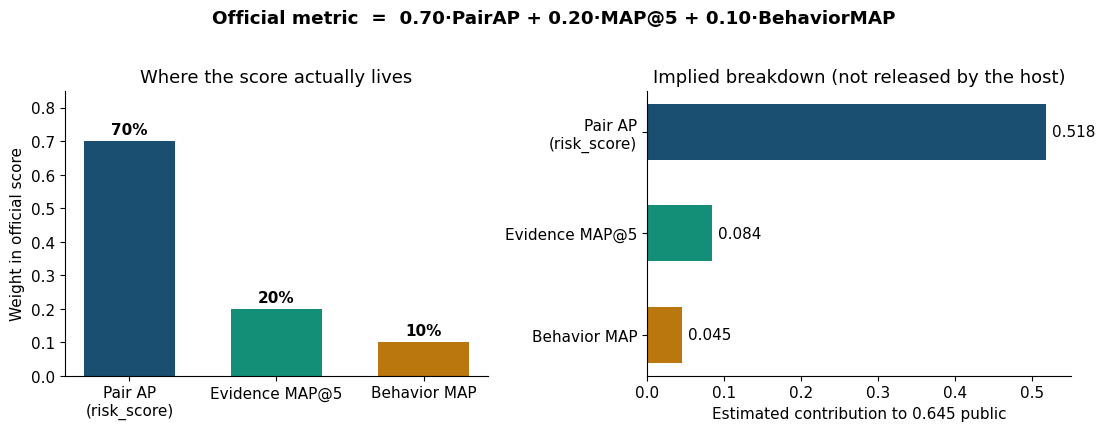

To move 0.645 → 0.80 you need Pair AP ~0.85 and MAP@5 ~0.65, not a deeper tree.


In [1]:
from __future__ import annotations

import gc
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import polars as pl
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

NAVY, TEAL, AMBER, SLATE, ROSE = "#1B4F72", "#148F77", "#B9770E", "#5D6D7E", "#922B21"

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))

# Metric weights
w_labels = ["Pair AP\n(risk_score)", "Evidence MAP@5", "Behavior MAP"]
w_vals = [0.70, 0.20, 0.10]
w_colors = [NAVY, TEAL, AMBER]
bars = axes[0].bar(w_labels, w_vals, color=w_colors, width=0.62)
axes[0].set_ylim(0, 0.85)
axes[0].set_ylabel("Weight in official score")
axes[0].set_title("Where the score actually lives")
for b, v in zip(bars, w_vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Rough decomposition of 0.645
# 0.70*0.74 + 0.20*0.42 + 0.10*0.45 ≈ 0.518+0.084+0.045 = 0.647
est = {"Pair AP": 0.74, "MAP@5": 0.42, "Behavior": 0.45}
contrib = [0.70 * est["Pair AP"], 0.20 * est["MAP@5"], 0.10 * est["Behavior"]]
axes[1].barh(w_labels[::-1], contrib[::-1], color=w_colors[::-1], height=0.55)
axes[1].set_xlim(0, 0.55)
axes[1].set_xlabel("Estimated contribution to 0.645 public")
axes[1].set_title("Implied breakdown (not released by the host)")
for y, v in enumerate(contrib[::-1]):
    axes[1].text(v + 0.008, y, f"{v:.3f}", va="center")
fig.suptitle("Official metric  =  0.70·PairAP + 0.20·MAP@5 + 0.10·BehaviorMAP", y=1.02, fontweight="bold")
fig.tight_layout()
plt.show()
print("To move 0.645 → 0.80 you need Pair AP ~0.85 and MAP@5 ~0.65, not a deeper tree.")


<a id="2"></a>
## 2. Data model and EDA

Raw tables used at train time (gameplay only; player identity is not a feature):

| File | Grain | What we use |
|---|---|---|
| `hands.parquet` | hand | `phase`, `table_id`, `started_at`, `big_blind`, `final_pot` |
| `seats.parquet` | player × hand | hole cards, `net_chips`, `total_contribution`, fold/showdown, `seat_no` |
| `actions.parquet` | action | `street`, `action`, `amount`, `to_call`, `players_active` |
| `development_labels.csv` | pair | 1,860 confirmed labels + family |
| `development_evidence.csv` | pair × hand | planted evidence hands for MAP@5 |
| `evaluation_pairs.csv` | pair | 112,540 pairs to score |

`players.parquet` is only used to locate the dataset directory. Feeding `player_id` into the model would be leakage.

The next cells profile **labels, evidence, and co-seating**. They run against the competition input when mounted; they do not require the feature cache.


Data: /kaggle/input/competitions/detect-suspicious-value-transfers-in-poker
Labels
shape: (4, 3)
┌───────┬───────────────────────┬──────┐
│ label ┆ behavior_family       ┆ len  │
│ ---   ┆ ---                   ┆ ---  │
│ i64   ┆ str                   ┆ u32  │
╞═══════╪═══════════════════════╪══════╡
│ 0     ┆ none                  ┆ 1488 │
│ 1     ┆ coordinated_isolation ┆ 92   │
│ 1     ┆ directed_transfer     ┆ 148  │
│ 1     ┆ soft_play             ┆ 132  │
└───────┴───────────────────────┴──────┘

Evidence rows 1,817 | unique pairs 372
Eval pairs 112,540
Hands by phase
shape: (2, 2)
┌─────────────┬─────────┐
│ phase       ┆ len     │
│ ---         ┆ ---     │
│ str         ┆ u32     │
╞═════════════╪═════════╡
│ development ┆ 1200000 │
│ evaluation  ┆ 800000  │
└─────────────┴─────────┘
Tables 400

Positive pairs 372 | unique colluder players 693
If colluders were disjoint pairs you would see 744 players. 693 ⇒ some players sit in multiple collusive pairs (cliques).


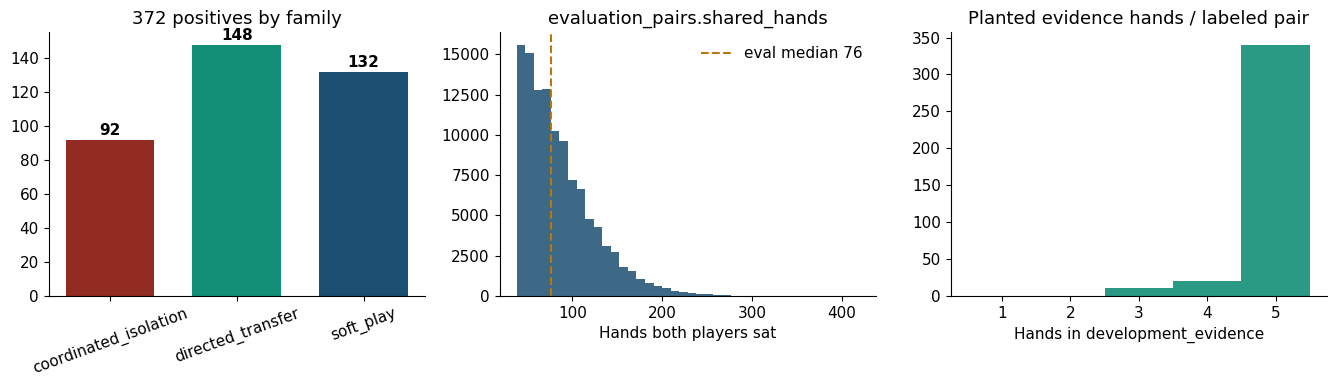

Eval shared_hands min=38 → PU filter uses ceil(1.5×min) = 57


In [2]:
# Shared constants / helpers (same as poker_kaggle.py)
SEED = 42
BEHAVIORS = ["directed_transfer", "soft_play", "coordinated_isolation"]
BEHAVIOR_TO_ID = {name: i + 1 for i, name in enumerate(BEHAVIORS)}
OUTPUT_DIR = Path("/kaggle/working")
REQUIRED_FILES = {
    "players.parquet", "hands.parquet", "seats.parquet", "actions.parquet",
    "development_labels.csv", "development_evidence.csv",
    "evaluation_pairs.csv", "sample_submission.csv",
}


def find_data_dir() -> Path:
    roots = [Path("/kaggle/input"), Path("data"), Path(".")]
    found = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("players.parquet"):
            parent = path.parent
            names = {child.name for child in parent.iterdir()}
            if REQUIRED_FILES.issubset(names):
                found.append(parent)
    unique = list(dict.fromkeys(found))
    if len(unique) != 1:
        raise FileNotFoundError(
            "Mount the competition dataset. "
            f"Found {len(unique)} compatible directories: {unique}"
        )
    return unique[0]


def add_pair_key(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.min_horizontal("player_1", "player_2").alias("p_low"),
        pl.max_horizontal("player_1", "player_2").alias("p_high"),
    )


DATA_OK = True
try:
    DATA_DIR = find_data_dir()
    print("Data:", DATA_DIR)
except FileNotFoundError as exc:
    DATA_OK = False
    DATA_DIR = None
    print(exc)
if not DATA_OK:
    print("Skip live EDA — competition input is not mounted.")
else:
    labels = pl.read_csv(DATA_DIR / "development_labels.csv")
    evidence = pl.read_csv(DATA_DIR / "development_evidence.csv")
    eval_pairs = pl.read_csv(DATA_DIR / "evaluation_pairs.csv")
    hands_meta = pl.scan_parquet(DATA_DIR / "hands.parquet").select(["hand_id", "phase", "table_id"]).collect()

    print("Labels")
    print(labels.group_by(["label", "behavior_family"]).len().sort(["label", "behavior_family"]))
    print("\nEvidence rows", f"{len(evidence):,}", "| unique pairs", evidence["pair_id"].n_unique())
    print("Eval pairs", f"{len(eval_pairs):,}")
    print("Hands by phase")
    print(hands_meta.group_by("phase").len().sort("phase"))
    print("Tables", hands_meta["table_id"].n_unique())

    pos = labels.filter(pl.col("label") == 1)
    colluders = pl.concat([pos["player_1"], pos["player_2"]]).n_unique()
    print(f"\nPositive pairs {len(pos):,} | unique colluder players {colluders:,}")
    print("If colluders were disjoint pairs you would see 744 players. "
          f"{colluders} ⇒ some players sit in multiple collusive pairs (cliques).")
if not DATA_OK:
    print("Skip plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

    fam = (
        labels.filter(pl.col("label") == 1)
        .group_by("behavior_family").len()
        .sort("behavior_family")
    )
    axes[0].bar(fam["behavior_family"].to_list(), fam["len"].to_list(), color=[ROSE, TEAL, NAVY], width=0.7)
    axes[0].set_title("372 positives by family")
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(fam["len"].to_list()):
        axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

    lab_sh = labels["shared_hands"].to_numpy() if "shared_hands" in labels.columns else None
    ev_sh = eval_pairs["shared_hands"].to_numpy()
    axes[1].hist(ev_sh, bins=40, color=NAVY, alpha=0.85)
    axes[1].axvline(np.median(ev_sh), color=AMBER, ls="--", label=f"eval median {np.median(ev_sh):.0f}")
    axes[1].set_title("evaluation_pairs.shared_hands")
    axes[1].set_xlabel("Hands both players sat")
    axes[1].legend(frameon=False)

    ev_per = evidence.group_by("pair_id").len()["len"].to_numpy()
    axes[2].hist(ev_per, bins=np.arange(1, ev_per.max() + 2) - 0.5, color=TEAL, alpha=0.9)
    axes[2].set_title("Planted evidence hands / labeled pair")
    axes[2].set_xlabel("Hands in development_evidence")
    fig.tight_layout()
    plt.show()

    print(f"Eval shared_hands min={ev_sh.min()} → PU filter uses ceil(1.5×min) = {int(np.ceil(ev_sh.min()*1.5))}")


### How to read this EDA

- **Three disclosed families, uneven counts.** Directed transfer is the largest (148). Isolation is the smallest (92) and, in every model we trained, the weakest one-vs-rest detector. That is a hint: isolation is a *sequence* (squeeze, then check-down), not a count of raises.
- **Evidence is sparse.** MAP@5 is computed on a handful of planted hands per pair. A pair-level mean of “looks a bit weird” is the wrong objective for 20% of the score; the ranker must put those specific hands in the top five.
- **Eval pairs are long-lived.** `shared_hands` on evaluation is typically tens of hands, not 2–3. Collusion, if planted, has room to show up as a *tail* (top-3 transfers, a burst of HU checks), which is why we keep `max` / `top5` / Gini rather than means alone.
- **693 colluders / 372 pairs.** Some players belong to more than one labeled pair. A later graph feature (boost B–C if A–B and A–C both look collusive) is justified by the data, but we did not ship it in the 0.645 run.


<a id="3"></a>
## 3. Positive-unlabeled sampling

Nomannic’s public 0.56 recipe is the right *shape* of PU, not nnPU theory:

| Group | \(y\) | `sample_weight` |
|---|---|---|
| 372 labeled positives | 1 | **2.0** |
| 1,488 confirmed negatives | 0 | **1.0** |
| 24,000 unlabeled (PU) | 0 | **0.35** |

PU pairs are **not** “any co-seated pair on a collusion table”. That experiment (unlabeled on tables that already have a positive, plus a table `XGBRanker`) **hurt** LB. The constraint that worked:

1. Not in the 1,860 labels.
2. Development `shared_hands ≥ 1.5 × min(eval shared_hands)` (here: **57**).
3. **Neither player is one of the 693 known colluders.**
4. Shuffle, then keep **60 pairs per `table_id`**.

A bug in an earlier draft used `_rid - min(_rid).over(table_id)` after a *global* shuffle. That is not a within-table rank, so each table contributed ~1 pair (464 PU, not 24,000). Public barely moved. The fix is ordinal rank of the shuffled index **within** `table_id`.

We still do **not** treat this as proper PU learning (Elkan–Noto / nnPU). Unlabeled rows are soft negatives so that 24k rows cannot drown 1,860. The behavior head is trained on positives only.


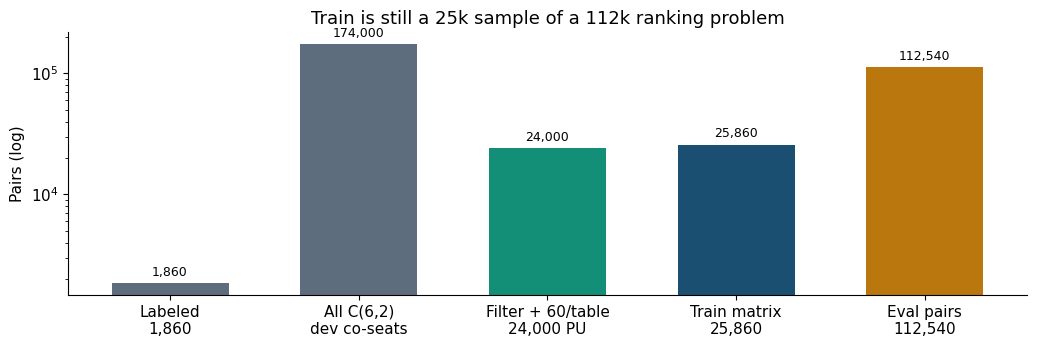

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 3.6))
stages = [
    ("Labeled\n1,860", 1860, SLATE),
    ("All C(6,2)\ndev co-seats", 435 * 400, SLATE),  # upper bound per table
    ("Filter + 60/table\n24,000 PU", 24000, TEAL),
    ("Train matrix\n25,860", 25860, NAVY),
    ("Eval pairs\n112,540", 112540, AMBER),
]
xs = np.arange(len(stages))
ax.bar(xs, [s[1] for s in stages], color=[s[2] for s in stages], width=0.62)
ax.set_xticks(xs)
ax.set_xticklabels([s[0] for s in stages])
ax.set_yscale("log")
ax.set_ylabel("Pairs (log)")
ax.set_title("Train is still a 25k sample of a 112k ranking problem")
for x, s in zip(xs, stages):
    ax.text(x, s[1] * 1.15, f"{s[1]:,}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()


<a id="4"></a>
## 4. System architecture

Everything is **tabular XGBoost**. Pair AP is an `XGBClassifier` (`binary:logistic`, `hist`). Evidence is one `XGBRanker` (`rank:pairwise`) plus a within-pair z-score blend with a family heuristic. We tried replacing the pair model with `XGBRanker` grouped by `table_id`; it lost.

The pipeline is cache-first (`/kaggle/working/prepared_pu24k`). Hand-level parquet is expensive (~3M development pair-hands). Aggregation, baselines, and models recompute every run.


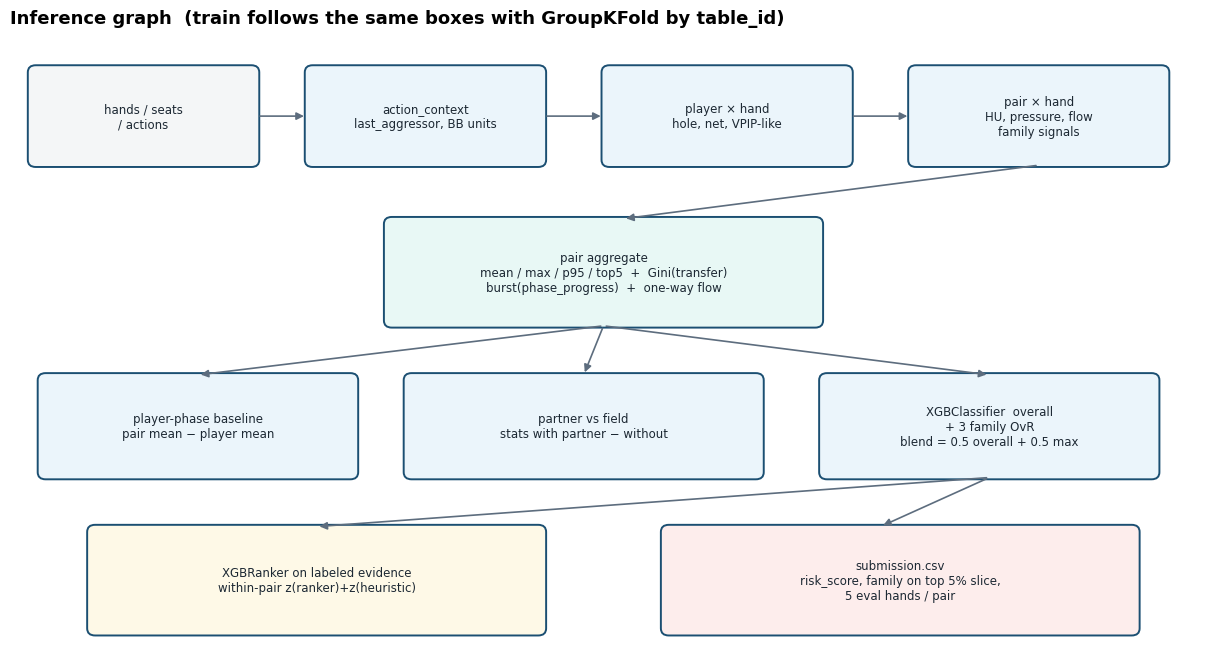

In [4]:
def _box(ax, x, y, w, h, text, fc="#EBF5FB", ec=NAVY):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=fc, edgecolor=ec, linewidth=1.4))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.5, color="#1C2833")


def _arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=SLATE, lw=1.2))


fig, ax = plt.subplots(figsize=(12.2, 6.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("Inference graph  (train follows the same boxes with GroupKFold by table_id)", loc="left", fontweight="bold")

_box(ax, 0.2, 5.5, 2.3, 1.1, "hands / seats\n/ actions", fc="#F4F6F7")
_box(ax, 3.0, 5.5, 2.4, 1.1, "action_context\nlast_aggressor, BB units")
_box(ax, 6.0, 5.5, 2.5, 1.1, "player × hand\nhole, net, VPIP-like")
_box(ax, 9.1, 5.5, 2.6, 1.1, "pair × hand\nHU, pressure, flow\nfamily signals")
_arrow(ax, 2.5, 6.05, 3.0, 6.05)
_arrow(ax, 5.4, 6.05, 6.0, 6.05)
_arrow(ax, 8.5, 6.05, 9.1, 6.05)

_box(ax, 3.8, 3.7, 4.4, 1.2, "pair aggregate\nmean / max / p95 / top5  +  Gini(transfer)\nburst(phase_progress)  +  one-way flow", fc="#E8F8F5")
_arrow(ax, 10.4, 5.5, 6.2, 4.9)

_box(ax, 0.3, 2.0, 3.2, 1.15, "player-phase baseline\npair mean − player mean")
_box(ax, 4.0, 2.0, 3.6, 1.15, "partner vs field\nstats with partner − without")
_box(ax, 8.2, 2.0, 3.4, 1.15, "XGBClassifier  overall\n+ 3 family OvR\nblend = 0.5 overall + 0.5 max")
_arrow(ax, 6.0, 3.7, 1.9, 3.15)
_arrow(ax, 6.0, 3.7, 5.8, 3.15)
_arrow(ax, 6.0, 3.7, 9.9, 3.15)

_box(ax, 0.8, 0.25, 4.6, 1.2, "XGBRanker on labeled evidence\nwithin-pair z(ranker)+z(heuristic)", fc="#FEF9E7")
_box(ax, 6.6, 0.25, 4.8, 1.2, "submission.csv\nrisk_score, family on top 5% slice,\n5 eval hands / pair", fc="#FDEDEC")
_arrow(ax, 9.9, 2.0, 3.1, 1.45)
_arrow(ax, 9.9, 2.0, 8.8, 1.45)
fig.tight_layout()
plt.show()


<a id="5"></a>
## 5. Feature philosophy by family

Collusion in this generator is **not one residual**. We build hand-level *signals* that match the three disclosed stories, then compress each pair with mean, max, p95, and top-5. Partner-vs-field (play when the partner is seated minus play when they are absent) is the contrast that survived ablation; a table-percentile blend of `risk_score` did not.

| Family | Story we encode | Hand / pair features |
|---|---|---|
| **directed_transfer** | One player donates chips | BB-normalized transfer both ways, `flow_oneway`, `flow_imbalance`, dump vs weak `loser_hole`, Gini / top-3 share of transfer, donor/receiver contrast (`directed_pf`) |
| **soft_play** | The pair refuses to fight each other | True heads-up checks/calls (partner still in), `strong_hole_passive`, negative aggression vs field (`soft_pf`, `soft_field`) |
| **coordinated_isolation** | Squeeze the field, then go quiet | Outsider folds to the pair’s aggression, pair raises, `isolation_pf`; isolation is still the weakest detector |

**Partner vs field** is computed from seats + player-hand stats, not from pair-hand parquet: for each pair, take player 1’s mean `net / aggression / raise / fold-to-bet` on hands where player 2 is also seated, subtract the same means on hands where player 1 sits and player 2 does not. Repeat for player 2. Soft play should look like *less* aggression with the partner; dumps look like *asymmetric* `net` contrast.

We **do not** use `player_id`, absolute timestamps, or row order as features. `phase_progress` is a within-table rank of `started_at`, used only for burst bins.


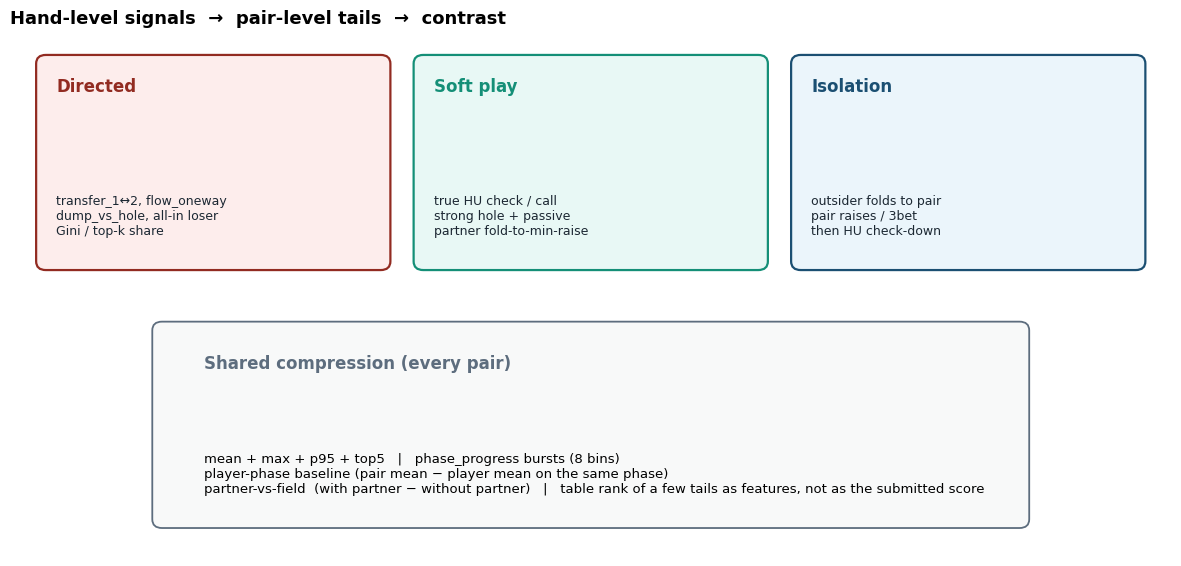

In [5]:
fig, ax = plt.subplots(figsize=(12.0, 5.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_title("Hand-level signals  →  pair-level tails  →  contrast", loc="left", fontweight="bold")

blocks = [
    (0.3, 3.3, 3.6, 2.4, "#FDEDEC", ROSE, "Directed",
     "transfer_1↔2, flow_oneway\ndump_vs_hole, all-in loser\nGini / top-k share"),
    (4.2, 3.3, 3.6, 2.4, "#E8F8F5", TEAL, "Soft play",
     "true HU check / call\nstrong hole + passive\npartner fold-to-min-raise"),
    (8.1, 3.3, 3.6, 2.4, "#EBF5FB", NAVY, "Isolation",
     "outsider folds to pair\npair raises / 3bet\nthen HU check-down"),
]
for x, y, w, h, fc, ec, title, body in blocks:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.1",
                                facecolor=fc, edgecolor=ec, lw=1.6))
    ax.text(x + 0.18, y + h - 0.38, title, fontsize=12, fontweight="bold", color=ec)
    ax.text(x + 0.18, y + 0.35, body, fontsize=9, va="bottom", color="#1C2833")

ax.add_patch(FancyBboxPatch((1.5, 0.35), 9.0, 2.3, boxstyle="round,pad=0.03,rounding_size=0.1",
                            facecolor="#F8F9F9", edgecolor=SLATE, lw=1.3))
ax.text(2.0, 2.15, "Shared compression (every pair)", fontsize=12, fontweight="bold", color=SLATE)
ax.text(2.0, 0.7,
        "mean + max + p95 + top5   |   phase_progress bursts (8 bins)\n"
        "player-phase baseline (pair mean − player mean on the same phase)\n"
        "partner-vs-field  (with partner − without partner)   |   table rank of a few tails as features, not as the submitted score",
        fontsize=9.5, va="bottom")
fig.tight_layout()
plt.show()


<a id="6"></a>
## 6. Models

### Pair risk (70%)

Five-fold `StratifiedGroupKFold` on `table_id` so a whole 30-player pool stays in train or validation. `XGBClassifier` with `eval_metric="aucpr"`, `sample_weight` as in §3. Three additional **one-vs-rest** classifiers, one per family (other families count as \(y=0\)).

Submitted `risk_score` is chosen on **PU-stress OOF** among:

- `overall` — the binary head  
- `family_max` — max of the three OvR scores  
- `max_all` — elementwise max of overall and family_max  
- `blend` — \(0.5\cdot\text{overall} + 0.5\cdot\text{family_max}\)

On the 24k-PU run, **blend** won (PU-stress **0.6174** vs overall 0.6055). Family_max alone was worse: the isolation detector is noisy (fold AP 0.66–0.87) while soft-play OvR is near-saturated on labeled data.

### Behavior (10%)

A 3-class head on **positives only**, compared with OvR argmax. We take the assignment with higher positive-family accuracy (OvR 0.978 on the 0.645 run). Families are written only on a global top slice of `risk_score`. A 5% slice scored **0.64469**. Tightening that slice with an elbow rule (cap 2%) scored **0.636** — Behavior MAP on eval wants a *wide* high-risk band, because not every collusive pair sits in the top 1%. We keep 5%.

### Evidence (20%)

Train `XGBRanker` only on labeled positive pairs’ development hands, target = planted evidence. At inference, for every eval pair:

1. Predict with the shared ranker.
2. Heuristic = the family signal matching the predicted family (`directed_signal` / `soft_signal` / `isolation_signal`).
3. **Z-score both within the pair**, blend 0.75 / 0.25 (if the ranker is constant on a pair, keep raw ranker scores).
4. Take top 5 hands. Always evaluation-period, both players present.

OOF MAP@5 sits around **0.45**. That is the largest unused official term after Pair AP.


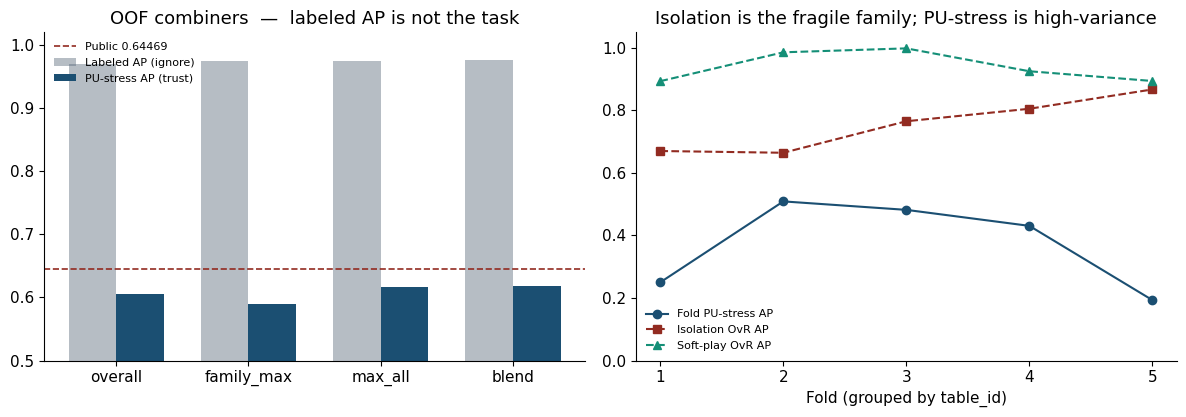

In [6]:
# Numbers from the 24k-PU + tier-A run that scored 0.64469
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))

names = ["overall", "family_max", "max_all", "blend"]
lab = [0.9696, 0.9744, 0.9751, 0.9763]
pu = [0.6055, 0.5893, 0.6171, 0.6174]
x = np.arange(len(names))
w = 0.36
axes[0].bar(x - w / 2, lab, w, label="Labeled AP (ignore)", color=SLATE, alpha=0.45)
axes[0].bar(x + w / 2, pu, w, label="PU-stress AP (trust)", color=NAVY)
axes[0].axhline(0.64469, color=ROSE, ls="--", lw=1.2, label="Public 0.64469")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_title("OOF combiners  —  labeled AP is not the task")
axes[0].legend(frameon=False, loc="upper left", fontsize=8)

folds = np.arange(1, 6)
pu_fold = [0.2503, 0.5091, 0.4820, 0.4308, 0.1933]
iso = [0.6703, 0.6647, 0.7655, 0.8055, 0.8673]
soft = [0.8938, 0.9861, 0.9987, 0.9255, 0.8943]
axes[1].plot(folds, pu_fold, "o-", color=NAVY, label="Fold PU-stress AP")
axes[1].plot(folds, iso, "s--", color=ROSE, label="Isolation OvR AP")
axes[1].plot(folds, soft, "^--", color=TEAL, label="Soft-play OvR AP")
axes[1].set_xticks(folds)
axes[1].set_xlabel("Fold (grouped by table_id)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Isolation is the fragile family; PU-stress is high-variance")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


<a id="7"></a>
## 7. Public ablation

One change per submit. Public scores below are this team’s ladder, not Nomannic’s.

| Step | What changed | Public |
|---|---|---|
| Confirmed-label XGB, table-score blend, `other_coordination` | 1,860 pairs only | ~0.46 |
| Drop table percentile blend; never predict `other_coordination` | Pair AP + Behavior | ~0.51 |
| PU intended, but **464 PU** (broken within-table rank) + flow + player baseline | Almost no extra negatives | ~0.61 |
| Partner-vs-field + transfer Gini + 3 family OvR on the **2,324-row** matrix | Features on the wrong train size | 0.62 |
| **Fix PU rank → 24,000 / 60 per table** + same tier-A features | First true Nomannic-shaped train set | **0.64469** |
| Elbow-cap family rate at ≤2% | Behavior MAP + evidence family flags | **0.636** (revert) |
| Table `XGBRanker` + unlabeled **on colluder tables** | Mixed two bad ideas | worse than 0.46 |

**Keep:** 60 PU / table, exclude the 693 colluder players, weight 0.35, partner-vs-field, 5% family slice, one evidence ranker with within-pair z-blend.

**Do not retry:** blending `risk_score` with within-table percentile (Pair AP is *global*), unlabeled on tables that already have a known positive, replacing the pair classifier with a table ranker, LightGBM/transformers before street templates.


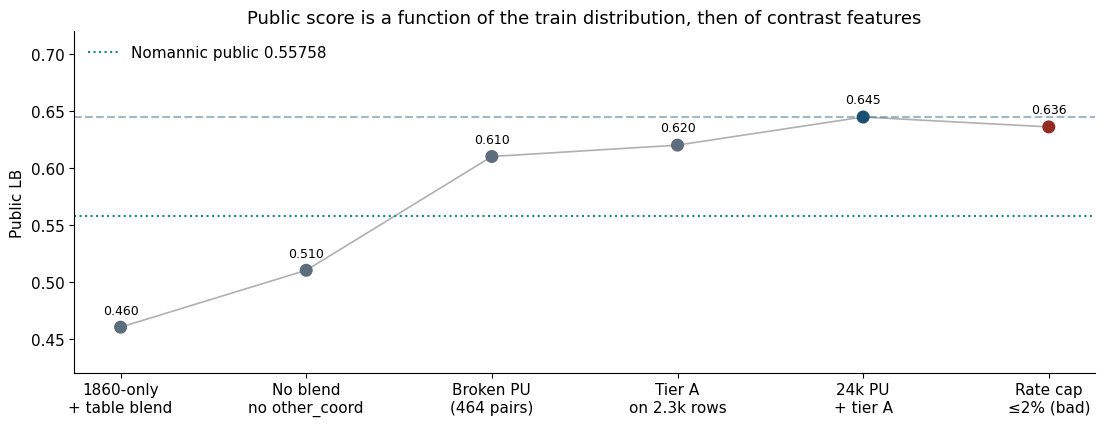

In [7]:
fig, ax = plt.subplots(figsize=(11.2, 4.4))
steps = [
    "1860-only\n+ table blend",
    "No blend\nno other_coord",
    "Broken PU\n(464 pairs)",
    "Tier A\non 2.3k rows",
    "24k PU\n+ tier A",
    "Rate cap\n≤2% (bad)",
]
scores = [0.46, 0.51, 0.61, 0.62, 0.64469, 0.636]
colors = [SLATE, SLATE, SLATE, SLATE, NAVY, ROSE]
ax.plot(range(len(steps)), scores, color="#B0B0B0", lw=1.2, zorder=1)
ax.scatter(range(len(steps)), scores, c=colors, s=70, zorder=2)
for i, s in enumerate(scores):
    ax.text(i, s + 0.012, f"{s:.3f}", ha="center", fontsize=9)
ax.axhline(0.55758, color=TEAL, ls=":", label="Nomannic public 0.55758")
ax.axhline(0.64469, color=NAVY, ls="--", alpha=0.4)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps)
ax.set_ylim(0.42, 0.72)
ax.set_ylabel("Public LB")
ax.set_title("Public score is a function of the train distribution, then of contrast features")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


<a id="8"></a>
## 8. Runnable pipeline

The next cell is the full implementation. The cell after that actually trains. On Kaggle, attach the competition, CPU only.

Cached pair-hands (`prepared_pu24k`) make a rerun ~10–15 minutes; a cold start is ~30–40 minutes.


In [8]:
from __future__ import annotations

import gc
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier, XGBRanker

SEED = 42
BEHAVIORS = ["directed_transfer", "soft_play", "coordinated_isolation"]
BEHAVIOR_TO_ID = {name: i + 1 for i, name in enumerate(BEHAVIORS)}
OUTPUT_DIR = Path("/kaggle/working")
REQUIRED_FILES = {
    "players.parquet",
    "hands.parquet",
    "seats.parquet",
    "actions.parquet",
    "development_labels.csv",
    "development_evidence.csv",
    "evaluation_pairs.csv",
    "sample_submission.csv",
}
PLAYER_COLS = [
    "pot_bb",
    "contribution_bb",
    "net_bb",
    "folded",
    "went_to_showdown",
    "won_share",
    "hole_strength",
    "n_actions",
    "aggressive_actions",
    "raises",
    "calls",
    "checks",
    "folds",
    "all_ins",
    "postflop_checks",
    "folds_facing_bet",
    "hu_actions",
    "max_amount_bb",
    "max_to_call_bb",
]
ACTION_COLS = PLAYER_COLS[8:]
RANK_BASE_CANDIDATES = [
    "directed_signal",
    "soft_signal",
    "isolation_signal",
    "other_signal",
    "transfer_any_bb",
    "flow_oneway",
    "dump_vs_hole",
    "net_gap_bb",
    "pot_bb",
    "true_hu_actions",
    "true_hu_checks",
    "true_hu_calls",
    "true_hu_aggression",
    "outsider_folds_to_pair",
    "partner_folds_to_pair",
    "partner_calls_to_pair",
    "pair_raises",
    "max_amount_bb",
    "both_showdown",
]
UNKNOWN_PER_TABLE = 60
PU_WEIGHT = 0.35
POS_WEIGHT = 2.0
BASELINE_COLS = ["net_bb", "aggressive_actions", "raises", "calls", "checks", "folds"]
FIELD_COLS = [
    "net_bb",
    "aggressive_actions",
    "raises",
    "calls",
    "checks",
    "folds",
    "folds_facing_bet",
    "all_ins",
    "contribution_bb",
]
SIDE_KEEP = [
    "net_bb_1",
    "net_bb_2",
    "aggressive_actions_1",
    "aggressive_actions_2",
    "raises_1",
    "raises_2",
    "calls_1",
    "calls_2",
    "checks_1",
    "checks_2",
    "folds_1",
    "folds_2",
    "transfer_1_to_2_bb",
    "transfer_2_to_1_bb",
]
FAMILY_FEATURES = ["family_directed", "family_soft", "family_isolation"]


def find_data_dir() -> Path:
    roots = [Path("/kaggle/input"), Path("data"), Path(".")]
    found = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("players.parquet"):
            parent = path.parent
            names = {child.name for child in parent.iterdir()}
            if REQUIRED_FILES.issubset(names):
                found.append(parent)
    unique = list(dict.fromkeys(found))
    if len(unique) != 1:
        raise FileNotFoundError(
            "Mount the competition dataset from Kaggle's Input panel. "
            f"Found {len(unique)} compatible directories: {unique}"
        )
    return unique[0]


def add_pair_key(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.min_horizontal("player_1", "player_2").alias("p_low"),
        pl.max_horizontal("player_1", "player_2").alias("p_high"),
    )


def card_rank(column: str) -> pl.Expr:
    rank = pl.col(column).cast(pl.Utf8).str.replace(r"[cdhsCDHS]$", "").str.to_uppercase()
    return (
        pl.when(rank == "A")
        .then(14)
        .when(rank == "K")
        .then(13)
        .when(rank == "Q")
        .then(12)
        .when(rank == "J")
        .then(11)
        .when(rank == "T")
        .then(10)
        .otherwise(rank.cast(pl.Int8, strict=False))
    )


def all_pair_hands(seats: pl.LazyFrame, hands: pl.LazyFrame, phase: str) -> pl.LazyFrame:
    hand_players = (
        seats.join(
            hands.filter(pl.col("phase") == phase).select(
                ["hand_id", "table_id", "started_at", "big_blind", "final_pot"]
            ),
            on="hand_id",
        )
        .group_by(["hand_id", "table_id", "started_at", "big_blind", "final_pot"])
        .agg(pl.col("player_id").sort_by("seat_no").alias("players"))
        .collect(engine="streaming")
        .sort(["table_id", "started_at", "hand_id"])
        .with_columns(
            (
                pl.col("started_at").rank("ordinal").over("table_id")
                / pl.len().over("table_id")
            )
            .cast(pl.Float32)
            .alias("phase_progress")
        )
    )
    frames = [
        hand_players.lazy().select(
            [
                "hand_id",
                "table_id",
                "big_blind",
                "final_pot",
                "phase_progress",
                pl.col("players").list.get(i).alias("a"),
                pl.col("players").list.get(j).alias("b"),
            ]
        )
        for i, j in combinations(range(6), 2)
    ]
    return pl.concat(frames).with_columns(
        pl.min_horizontal("a", "b").alias("p_low"),
        pl.max_horizontal("a", "b").alias("p_high"),
    ).drop(["a", "b"])


def pair_occurrence_counts(all_pairs: pl.LazyFrame) -> pl.DataFrame:
    return (
        all_pairs.group_by(["p_low", "p_high"])
        .agg(
            pl.col("table_id").first(),
            pl.len().cast(pl.Int32).alias("shared_hands"),
        )
        .collect(engine="streaming")
    )


def player_phase_baselines(player_hand_path: Path, phase: str) -> pl.DataFrame:
    return (
        pl.scan_parquet(player_hand_path)
        .filter(pl.col("phase") == phase)
        .group_by("player_id")
        .agg(
            pl.len().alias("n_hands_base"),
            *[pl.col(c).cast(pl.Float64).mean().alias(f"{c}_base") for c in BASELINE_COLS],
        )
        .collect()
    )


def add_player_baselines(df: pl.DataFrame, baselines: pl.DataFrame) -> pl.DataFrame:
    out = df
    for prefix, player_col in (("p1", "player_1"), ("p2", "player_2")):
        renamed = baselines.rename(
            {c: (player_col if c == "player_id" else f"{prefix}_{c}") for c in baselines.columns}
        )
        out = out.join(renamed, on=player_col, how="left")
    exprs = []
    for side, prefix in ((1, "p1"), (2, "p2")):
        for col in BASELINE_COLS:
            pair_col = f"{col}_{side}_mean"
            base_col = f"{prefix}_{col}_base"
            if pair_col in out.columns and base_col in out.columns:
                exprs.append((pl.col(pair_col) - pl.col(base_col)).cast(pl.Float32).alias(f"{prefix}_{col}_contrast"))
    if not exprs:
        return out
    out = out.with_columns(exprs)
    extra = []
    if "p1_net_bb_contrast" in out.columns and "p2_net_bb_contrast" in out.columns:
        extra += [
            (pl.col("p1_net_bb_contrast") + pl.col("p2_net_bb_contrast")).alias("pair_net_contrast"),
            (pl.col("p1_net_bb_contrast") - pl.col("p2_net_bb_contrast")).abs().alias("directed_asymm"),
        ]
    if "p1_aggressive_actions_contrast" in out.columns and "p2_aggressive_actions_contrast" in out.columns:
        extra += [
            (
                -(pl.col("p1_aggressive_actions_contrast") + pl.col("p2_aggressive_actions_contrast"))
            ).alias("soft_field"),
            (
                pl.col("p1_aggressive_actions_contrast") + pl.col("p2_aggressive_actions_contrast")
            ).alias("pair_agr_contrast"),
        ]
    if "p1_raises_contrast" in out.columns and "p2_raises_contrast" in out.columns:
        extra.append((pl.col("p1_raises_contrast") + pl.col("p2_raises_contrast")).alias("pair_raise_contrast"))
    if extra:
        out = out.with_columns(extra)
    drop_base = [c for c in out.columns if c.endswith("_base")]
    return out.drop(drop_base) if drop_base else out


def add_one_way_flow(df: pl.DataFrame) -> pl.DataFrame:
    s12 = "transfer_1_to_2_bb_sum"
    s21 = "transfer_2_to_1_bb_sum"
    if s12 not in df.columns or s21 not in df.columns:
        return df
    return df.with_columns(
        (
            (pl.col(s12).fill_null(0) - pl.col(s21).fill_null(0)).abs()
            / (pl.col(s12).fill_null(0) + pl.col(s21).fill_null(0) + 1.0)
        )
        .cast(pl.Float32)
        .alias("flow_imbalance"),
        pl.max_horizontal(pl.col(s12).fill_null(0), pl.col(s21).fill_null(0))
        .cast(pl.Float32)
        .alias("flow_dominant"),
    )


def add_transfer_concentration(hand_path: Path, out: pl.DataFrame) -> pl.DataFrame:
    src = pl.scan_parquet(hand_path)
    needed = {"transfer_any_bb", "flow_oneway"}
    cols = set(src.collect_schema().names())
    if not needed.issubset(cols):
        return out
    conc = src.group_by("pair_id").agg(
        pl.col("transfer_any_bb").sum().alias("transfer_any_bb_sum"),
        pl.col("transfer_any_bb").max().alias("_t_max"),
        pl.col("transfer_any_bb").top_k(3).sum().alias("transfer_top3_sum"),
        pl.col("transfer_any_bb").top_k(5).sum().alias("transfer_top5_sum"),
        pl.col("flow_oneway").sum().alias("flow_oneway_sum"),
        pl.col("flow_oneway").top_k(5).sum().alias("flow_oneway_top5_sum"),
    )
    gini = (
        src.select(["pair_id", "transfer_any_bb"])
        .with_columns(pl.col("transfer_any_bb").clip(lower_bound=0).alias("_x"))
        .group_by("pair_id")
        .agg(
            pl.len().alias("_n"),
            pl.col("_x").sum().alias("_s"),
            (pl.col("_x") * pl.col("_x").rank("ordinal")).sum().alias("_w"),
        )
        .with_columns(
            pl.when(pl.col("_s") <= 0)
            .then(0.0)
            .otherwise((2.0 * pl.col("_w")) / (pl.col("_n") * pl.col("_s")) - (pl.col("_n") + 1) / pl.col("_n"))
            .cast(pl.Float32)
            .alias("transfer_gini")
        )
        .select(["pair_id", "transfer_gini"])
    )
    extra = conc.join(gini, on="pair_id", how="left").collect(engine="streaming")
    overlap = [c for c in extra.columns if c != "pair_id" and c in out.columns]
    if overlap:
        out = out.drop(overlap)
    out = out.join(extra, on="pair_id", how="left")
    s = pl.col("transfer_any_bb_sum").fill_null(0)
    return out.with_columns(
        (pl.col("transfer_top3_sum").fill_null(0) / (s + 1.0)).cast(pl.Float32).alias("transfer_top3_share"),
        (pl.col("transfer_top5_sum").fill_null(0) / (s + 1.0)).cast(pl.Float32).alias("transfer_top5_share"),
        (pl.col("_t_max").fill_null(0) / (s + 1.0)).cast(pl.Float32).alias("transfer_max_share"),
        (
            pl.col("flow_oneway_top5_sum").fill_null(0)
            / (pl.col("flow_oneway_sum").fill_null(0) + 1.0)
        )
        .cast(pl.Float32)
        .alias("flow_top5_share"),
    ).drop("_t_max")


def _partner_field_side(
    pair_keys: pl.LazyFrame,
    occ: pl.LazyFrame,
    stats: pl.LazyFrame,
    prefix: str,
    player_col: str,
    partner_col: str,
    cols: list[str],
) -> pl.DataFrame:
    seated = (
        pair_keys.join(occ, left_on=[player_col, "table_id"], right_on=["player_id", "table_id"])
        .join(
            occ.select(["hand_id", "player_id", pl.lit(1).alias("_present")]),
            left_on=["hand_id", partner_col],
            right_on=["hand_id", "player_id"],
            how="left",
        )
        .with_columns(pl.col("_present").is_not_null().alias("_with"))
        .join(stats, left_on=["hand_id", player_col], right_on=["hand_id", "player_id"], how="left")
        .group_by(["pair_id", "_with"])
        .agg(
            pl.len().alias(f"{prefix}_n"),
            *[pl.col(c).cast(pl.Float64).mean().alias(f"{prefix}_{c}") for c in cols],
        )
        .collect(engine="streaming")
    )
    with_p = seated.filter(pl.col("_with")).drop("_with").rename(
        {c: f"{c}_with" for c in seated.columns if c not in ("pair_id", "_with")}
    )
    field = seated.filter(~pl.col("_with")).drop("_with").rename(
        {c: f"{c}_field" for c in seated.columns if c not in ("pair_id", "_with")}
    )
    keys = seated.select("pair_id").unique()
    return keys.join(with_p, on="pair_id", how="left").join(field, on="pair_id", how="left")


def add_partner_field_contrasts(
    df: pl.DataFrame,
    seats: pl.LazyFrame,
    hands: pl.LazyFrame,
    player_hand_path: Path,
    phase: str,
) -> pl.DataFrame:
    need = {"pair_id", "player_1", "player_2", "table_id"}
    if not need.issubset(df.columns):
        return df
    occ = (
        seats.join(hands.select(["hand_id", "table_id", "phase"]), on="hand_id")
        .filter(pl.col("phase") == phase)
        .select(["hand_id", "table_id", "player_id"])
    )
    available = set(pl.scan_parquet(player_hand_path).collect_schema().names())
    cols = [c for c in FIELD_COLS if c in available]
    if not cols:
        return df
    stats = pl.scan_parquet(player_hand_path).select(["hand_id", "player_id", *cols])
    pair_keys = df.select(["pair_id", "player_1", "player_2", "table_id"]).unique().lazy()
    p1 = _partner_field_side(pair_keys, occ, stats, "p1", "player_1", "player_2", cols)
    p2 = _partner_field_side(pair_keys, occ, stats, "p2", "player_2", "player_1", cols)
    out = df.join(p1, on="pair_id", how="left").join(p2, on="pair_id", how="left")
    exprs = []
    for prefix in ("p1", "p2"):
        n_with = f"{prefix}_n_with"
        n_field = f"{prefix}_n_field"
        if n_with in out.columns and n_field in out.columns:
            exprs.append(
                (pl.col(n_with).fill_null(0) / (pl.col(n_with).fill_null(0) + pl.col(n_field).fill_null(0) + 1.0))
                .cast(pl.Float32)
                .alias(f"{prefix}_with_share")
            )
        for col in cols:
            w, f = f"{prefix}_{col}_with", f"{prefix}_{col}_field"
            if w in out.columns and f in out.columns:
                exprs.append((pl.col(w).fill_null(0) - pl.col(f).fill_null(0)).cast(pl.Float32).alias(f"{prefix}_{col}_pf"))
    if exprs:
        out = out.with_columns(exprs)
    extra_exprs = []
    if "p1_net_bb_pf" in out.columns and "p2_net_bb_pf" in out.columns:
        extra_exprs += [
            (pl.col("p1_net_bb_pf") + pl.col("p2_net_bb_pf")).alias("pair_net_pf"),
            (pl.col("p1_net_bb_pf") - pl.col("p2_net_bb_pf")).abs().alias("directed_pf"),
        ]
    if "p1_aggressive_actions_pf" in out.columns and "p2_aggressive_actions_pf" in out.columns:
        extra_exprs.append(
            (-(pl.col("p1_aggressive_actions_pf") + pl.col("p2_aggressive_actions_pf"))).alias("soft_pf")
        )
    if "p1_raises_pf" in out.columns and "p2_raises_pf" in out.columns:
        extra_exprs.append((pl.col("p1_raises_pf") + pl.col("p2_raises_pf")).alias("isolation_pf"))
    if "p1_folds_facing_bet_pf" in out.columns and "p2_folds_facing_bet_pf" in out.columns:
        extra_exprs.append(
            (pl.col("p1_folds_facing_bet_pf") + pl.col("p2_folds_facing_bet_pf")).alias("pair_fold_pressure_pf")
        )
    if extra_exprs:
        out = out.with_columns(extra_exprs)
    drop_raw = [
        c
        for c in out.columns
        if (c.endswith("_with") or c.endswith("_field")) and not c.endswith("_n_with") and not c.endswith("_n_field")
    ]
    return out.drop(drop_raw) if drop_raw else out


def combine_risk_candidates(overall: np.ndarray, family_scores: np.ndarray) -> dict[str, np.ndarray]:
    fam_max = family_scores.max(axis=1).astype(np.float32)
    return {
        "overall": overall.astype(np.float32),
        "family_max": fam_max,
        "max_all": np.maximum(overall, fam_max).astype(np.float32),
        "blend": (0.5 * overall + 0.5 * fam_max).astype(np.float32),
    }


def safe_ap(y: np.ndarray, scores: np.ndarray, sample_weight: np.ndarray | None = None) -> float:
    if len(y) == 0 or y.max() == y.min():
        return 0.0
    return float(average_precision_score(y, scores, sample_weight=sample_weight))


def pu_stress_ap(y: np.ndarray, scores: np.ndarray, is_pu: np.ndarray, n_eval: int) -> float:
    n_pu = int(is_pu.sum())
    weight = np.where(is_pu, n_eval / max(n_pu, 1), 1.0).astype(np.float64)
    return safe_ap(y, scores, sample_weight=weight)


def build_action_context(actions: pl.LazyFrame, hands: pl.LazyFrame, path: Path) -> None:
    if path.exists():
        return
    aggressive = ["bet", "raise"]
    (
        actions.join(hands.select(["hand_id", "big_blind"]), on="hand_id")
        .sort(["hand_id", "action_no"])
        .with_columns(
            (
                pl.col("action").is_in(aggressive)
                | ((pl.col("action") == "all_in") & (pl.col("amount") > pl.col("to_call")))
            ).alias("is_aggressive")
        )
        .with_columns(
            pl.when(pl.col("is_aggressive"))
            .then(pl.col("player_id"))
            .otherwise(None)
            .alias("_aggressor")
        )
        .with_columns(
            pl.col("_aggressor")
            .shift(1)
            .forward_fill()
            .over(["hand_id", "street"])
            .alias("last_aggressor"),
            (pl.col("amount") / pl.col("big_blind")).cast(pl.Float32).alias("amount_bb"),
            (pl.col("to_call") / pl.col("big_blind")).cast(pl.Float32).alias("to_call_bb"),
        )
        .select(
            [
                "hand_id",
                "action_no",
                "street",
                "player_id",
                "action",
                "to_call",
                "players_active",
                "is_aggressive",
                "last_aggressor",
                "amount_bb",
                "to_call_bb",
            ]
        )
        .sink_parquet(path)
    )


def build_player_hands(
    seats: pl.LazyFrame,
    hands: pl.LazyFrame,
    action_path: Path,
    out_path: Path,
) -> None:
    if out_path.exists():
        return
    action_by_player = (
        pl.scan_parquet(action_path)
        .group_by(["hand_id", "player_id"])
        .agg(
            pl.len().cast(pl.Int16).alias("n_actions"),
            pl.col("is_aggressive").sum().cast(pl.Int16).alias("aggressive_actions"),
            (pl.col("action") == "raise").sum().cast(pl.Int16).alias("raises"),
            (pl.col("action") == "call").sum().cast(pl.Int16).alias("calls"),
            (pl.col("action") == "check").sum().cast(pl.Int16).alias("checks"),
            (pl.col("action") == "fold").sum().cast(pl.Int16).alias("folds"),
            (pl.col("action") == "all_in").sum().cast(pl.Int16).alias("all_ins"),
            ((pl.col("street") != "preflop") & (pl.col("action") == "check"))
            .sum()
            .cast(pl.Int16)
            .alias("postflop_checks"),
            ((pl.col("action") == "fold") & (pl.col("to_call") > 0))
            .sum()
            .cast(pl.Int16)
            .alias("folds_facing_bet"),
            (pl.col("players_active") == 2).sum().cast(pl.Int16).alias("hu_actions"),
            pl.col("amount_bb").max().fill_null(0).cast(pl.Float32).alias("max_amount_bb"),
            pl.col("to_call_bb").max().fill_null(0).cast(pl.Float32).alias("max_to_call_bb"),
        )
    )
    (
        seats.join(hands.select(["hand_id", "phase", "big_blind", "final_pot"]), on="hand_id")
        .with_columns(
            card_rank("hole_card_1").alias("r1"),
            card_rank("hole_card_2").alias("r2"),
            (pl.col("total_contribution") / pl.col("big_blind")).cast(pl.Float32).alias("contribution_bb"),
            (pl.col("net_chips") / pl.col("big_blind")).cast(pl.Float32).alias("net_bb"),
            (pl.col("final_pot") / pl.col("big_blind")).cast(pl.Float32).alias("pot_bb"),
        )
        .with_columns(
            (
                pl.max_horizontal("r1", "r2")
                + 7 * (pl.col("r1") == pl.col("r2")).cast(pl.Int8)
                + 1.5
                * (
                    pl.col("hole_card_1").str.slice(-1, 1)
                    == pl.col("hole_card_2").str.slice(-1, 1)
                ).cast(pl.Int8)
            )
            .cast(pl.Float32)
            .alias("hole_strength")
        )
        .join(action_by_player, on=["hand_id", "player_id"], how="left")
        .with_columns([pl.col(c).fill_null(0) for c in ACTION_COLS])
        .select(["hand_id", "player_id", "phase", *PLAYER_COLS])
        .sink_parquet(out_path)
    )


def player_side(player_hand_path: Path, side: str, player_col: str) -> pl.LazyFrame:
    return pl.scan_parquet(player_hand_path).select(
        "hand_id",
        pl.col("player_id").alias(player_col),
        *[pl.col(c).alias(f"{c}_{side}") for c in PLAYER_COLS],
    )


def build_pair_hand_features(
    pair_hands_path: Path,
    pairs_path: Path,
    player_hand_path: Path,
    action_path: Path,
    out_path: Path,
) -> None:
    if out_path.exists():
        return

    pair_base = pl.scan_parquet(pair_hands_path).join(
        pl.scan_parquet(pairs_path).select(["pair_id", "player_1", "player_2"]),
        on="pair_id",
    )
    p1 = player_side(player_hand_path, "1", "player_1")
    p2 = player_side(player_hand_path, "2", "player_2")

    hand = pair_base.join(p1, on=["hand_id", "player_1"]).join(p2, on=["hand_id", "player_2"]).with_columns(
        (pl.col("contribution_bb_1") + pl.col("contribution_bb_2")).alias("pair_contribution_bb"),
        (pl.col("net_bb_1") - pl.col("net_bb_2")).abs().alias("net_gap_bb"),
        pl.max_horizontal("net_bb_1", "net_bb_2").alias("max_win_bb"),
        (-pl.min_horizontal("net_bb_1", "net_bb_2")).alias("max_loss_bb"),
        pl.min_horizontal(
            (-pl.col("net_bb_1")).clip(lower_bound=0),
            pl.col("net_bb_2").clip(lower_bound=0),
        ).alias("transfer_1_to_2_bb"),
        pl.min_horizontal(
            (-pl.col("net_bb_2")).clip(lower_bound=0),
            pl.col("net_bb_1").clip(lower_bound=0),
        ).alias("transfer_2_to_1_bb"),
        (pl.col("went_to_showdown_1") & pl.col("went_to_showdown_2")).cast(pl.Int8).alias("both_showdown"),
        (pl.col("folded_1") ^ pl.col("folded_2")).cast(pl.Int8).alias("one_folded"),
        (pl.col("aggressive_actions_1") + pl.col("aggressive_actions_2")).alias("pair_aggression"),
        (pl.col("raises_1") + pl.col("raises_2")).alias("pair_raises"),
        (pl.col("calls_1") + pl.col("calls_2")).alias("pair_calls"),
        (pl.col("checks_1") + pl.col("checks_2")).alias("pair_checks"),
        (pl.col("postflop_checks_1") + pl.col("postflop_checks_2")).alias("pair_postflop_checks"),
        (pl.col("folds_facing_bet_1") + pl.col("folds_facing_bet_2")).alias("pair_pressure_folds"),
        (pl.col("hu_actions_1") + pl.col("hu_actions_2")).alias("pair_hu_actions"),
        pl.max_horizontal("hole_strength_1", "hole_strength_2").alias("max_hole_strength"),
        pl.min_horizontal("hole_strength_1", "hole_strength_2").alias("min_hole_strength"),
        pl.max_horizontal("max_amount_bb_1", "max_amount_bb_2").alias("max_amount_bb"),
        pl.max_horizontal("max_to_call_bb_1", "max_to_call_bb_2").alias("max_to_call_bb"),
        pl.when(pl.col("net_bb_1") <= pl.col("net_bb_2"))
        .then(pl.col("hole_strength_1"))
        .otherwise(pl.col("hole_strength_2"))
        .alias("loser_hole"),
        pl.when(pl.col("net_bb_1") > pl.col("net_bb_2"))
        .then(pl.col("hole_strength_1"))
        .otherwise(pl.col("hole_strength_2"))
        .alias("winner_hole"),
    )

    members = pl.concat(
        [
            pair_base.select(
                [
                    "pair_id",
                    "hand_id",
                    pl.col("player_1").alias("member"),
                    pl.col("player_2").alias("partner"),
                    pl.lit(1).alias("is_p1"),
                ]
            ),
            pair_base.select(
                [
                    "pair_id",
                    "hand_id",
                    pl.col("player_2").alias("member"),
                    pl.col("player_1").alias("partner"),
                    pl.lit(0).alias("is_p1"),
                ]
            ),
        ]
    )
    action_context = pl.scan_parquet(action_path)
    fold_at = (
        action_context.filter(pl.col("action") == "fold")
        .group_by(["hand_id", "player_id"])
        .agg(pl.col("action_no").min().alias("partner_fold_no"))
        .rename({"player_id": "partner"})
    )
    member_actions = (
        members.join(action_context, left_on=["hand_id", "member"], right_on=["hand_id", "player_id"], how="left")
        .join(fold_at, on=["hand_id", "partner"], how="left")
        .with_columns(
            (
                (pl.col("players_active") == 2)
                & (pl.col("partner_fold_no").is_null() | (pl.col("partner_fold_no") > pl.col("action_no")))
            ).alias("true_pair_hu")
        )
    )
    interaction = member_actions.group_by(["pair_id", "hand_id"]).agg(
        pl.col("true_pair_hu").sum().alias("true_hu_actions"),
        (pl.col("true_pair_hu") & (pl.col("action") == "check")).sum().alias("true_hu_checks"),
        (pl.col("true_pair_hu") & (pl.col("action") == "call")).sum().alias("true_hu_calls"),
        (pl.col("true_pair_hu") & pl.col("is_aggressive")).sum().alias("true_hu_aggression"),
        (pl.col("true_pair_hu") & pl.col("action").is_in(["check", "call"]) & (pl.col("is_p1") == 1))
        .sum()
        .alias("p1_hu_passive"),
        (pl.col("true_pair_hu") & pl.col("action").is_in(["check", "call"]) & (pl.col("is_p1") == 0))
        .sum()
        .alias("p2_hu_passive"),
    )
    responses = action_context.filter(
        (pl.col("to_call") > 0) & pl.col("last_aggressor").is_not_null()
    ).select(
        "hand_id",
        pl.col("last_aggressor").alias("member"),
        pl.col("player_id").alias("responder"),
        "action",
        "is_aggressive",
    )
    pressure = (
        members.join(responses, on=["hand_id", "member"], how="inner")
        .with_columns((pl.col("responder") == pl.col("partner")).alias("partner_response"))
        .group_by(["pair_id", "hand_id"])
        .agg(
            (pl.col("partner_response") & (pl.col("action") == "fold")).sum().alias("partner_folds_to_pair"),
            (pl.col("partner_response") & pl.col("action").is_in(["call", "all_in"]) & ~pl.col("is_aggressive"))
            .sum()
            .alias("partner_calls_to_pair"),
            (pl.col("partner_response") & pl.col("is_aggressive")).sum().alias("partner_raises_to_pair"),
            (~pl.col("partner_response") & (pl.col("action") == "fold")).sum().alias("outsider_folds_to_pair"),
            (~pl.col("partner_response") & (pl.col("action") == "call")).sum().alias("outsider_calls_to_pair"),
            (~pl.col("partner_response") & pl.col("is_aggressive")).sum().alias("outsider_raises_to_pair"),
        )
    )
    fill_cols = [
        "true_hu_actions",
        "true_hu_checks",
        "true_hu_calls",
        "true_hu_aggression",
        "p1_hu_passive",
        "p2_hu_passive",
        "partner_folds_to_pair",
        "partner_calls_to_pair",
        "partner_raises_to_pair",
        "outsider_folds_to_pair",
        "outsider_calls_to_pair",
        "outsider_raises_to_pair",
    ]
    result = (
        hand.join(interaction, on=["pair_id", "hand_id"], how="left")
        .join(pressure, on=["pair_id", "hand_id"], how="left")
        .with_columns([pl.col(c).fill_null(0) for c in fill_cols])
        .with_columns(
            pl.max_horizontal("transfer_1_to_2_bb", "transfer_2_to_1_bb").alias("transfer_any_bb"),
            (pl.col("transfer_1_to_2_bb") - pl.col("transfer_2_to_1_bb")).abs().alias("flow_oneway"),
            (pl.col("pair_contribution_bb") / (pl.col("pot_bb_1") + 1e-3)).clip(0, 2).alias("pair_pot_share"),
            (pl.col("loser_hole") * pl.max_horizontal("transfer_1_to_2_bb", "transfer_2_to_1_bb") / 14.0)
            .cast(pl.Float32)
            .alias("dump_vs_hole"),
            (
                (pl.col("min_hole_strength") >= 12)
                & (pl.col("pair_aggression") == 0)
                & (pl.col("both_showdown") == 1)
            )
            .cast(pl.Int8)
            .alias("strong_hole_passive"),
        )
        .with_columns(
            (
                pl.col("transfer_any_bb").log1p()
                + 0.45 * pl.col("flow_oneway").log1p()
                + 0.35 * pl.col("dump_vs_hole").log1p()
                + 0.3 * pl.col("max_amount_bb").log1p()
                + 0.4 * pl.col("both_showdown")
                + 0.2 * pl.col("true_hu_actions").log1p()
            ).alias("directed_signal"),
            (
                (pl.col("true_hu_checks") + pl.col("true_hu_calls") + pl.col("partner_calls_to_pair")).log1p()
                + 0.3 * pl.col("both_showdown")
                + 0.4 * pl.col("strong_hole_passive")
                - 0.4 * pl.col("true_hu_aggression").log1p()
            ).alias("soft_signal"),
            (
                (2 * pl.col("outsider_folds_to_pair") + pl.col("pair_raises")).log1p()
                + 0.3 * pl.col("partner_folds_to_pair")
                - 0.2 * pl.col("partner_raises_to_pair")
            ).alias("isolation_signal"),
        )
        .with_columns(
            (
                0.45 * pl.col("true_hu_actions").log1p()
                + 0.25 * pl.col("both_showdown")
                + 0.2 * pl.col("pair_contribution_bb").log1p()
                + 0.15 * pl.col("outsider_folds_to_pair").log1p()
                - 0.2
                * pl.max_horizontal("directed_signal", "soft_signal", "isolation_signal").clip(lower_bound=0)
            ).alias("other_signal")
        )
        .select(
            [
                "pair_id",
                "hand_id",
                "table_id",
                "phase_progress",
                "pot_bb_1",
                "pair_contribution_bb",
                "pair_pot_share",
                "net_gap_bb",
                "max_win_bb",
                "max_loss_bb",
                "transfer_any_bb",
                "flow_oneway",
                "dump_vs_hole",
                "max_hole_strength",
                "min_hole_strength",
                "loser_hole",
                "winner_hole",
                "strong_hole_passive",
                "both_showdown",
                "one_folded",
                "pair_aggression",
                "pair_raises",
                "pair_calls",
                "pair_checks",
                "pair_postflop_checks",
                "pair_pressure_folds",
                "pair_hu_actions",
                "max_amount_bb",
                "max_to_call_bb",
                *SIDE_KEEP,
                *fill_cols,
                "directed_signal",
                "soft_signal",
                "isolation_signal",
                "other_signal",
            ]
        )
        .rename({"pot_bb_1": "pot_bb"})
    )
    result.sink_parquet(out_path)


def numeric_hand_features(path: Path) -> list[str]:
    skip = {"pair_id", "hand_id", "table_id"}
    schema = pl.scan_parquet(path).collect_schema()
    return [c for c, dtype in schema.items() if dtype.is_numeric() and c not in skip]


def burst_features(hand_path: Path) -> pl.LazyFrame:
    return (
        pl.scan_parquet(hand_path)
        .with_columns(((pl.col("phase_progress") * 8).floor().clip(0, 7)).cast(pl.Int8).alias("bin"))
        .group_by(["pair_id", "bin"])
        .agg(
            pl.col("directed_signal").mean().alias("d"),
            pl.col("soft_signal").mean().alias("s"),
            pl.col("isolation_signal").mean().alias("i"),
            pl.col("other_signal").mean().alias("o"),
        )
        .group_by("pair_id")
        .agg(
            pl.col("d").max().alias("directed_burst_max"),
            pl.col("s").max().alias("soft_burst_max"),
            pl.col("i").max().alias("isolation_burst_max"),
            pl.col("o").max().alias("other_burst_max"),
            (pl.col("d").max() - pl.col("d").mean()).alias("directed_burst_excess"),
            (pl.col("s").max() - pl.col("s").mean()).alias("soft_burst_excess"),
            (pl.col("i").max() - pl.col("i").mean()).alias("isolation_burst_excess"),
        )
    )


def aggregate_pair_features(hand_path: Path, pairs: pl.DataFrame) -> pl.DataFrame:
    hand_feats = numeric_hand_features(hand_path)
    tail = [
        c
        for c in hand_feats
        if any(
            token in c
            for token in (
                "signal",
                "pot_bb",
                "contribution",
                "net_gap",
                "transfer",
                "amount",
                "raise",
                "hu_",
                "partner",
                "outsider",
                "dump",
                "hole",
                "burst",
                "flow",
            )
        )
    ]
    agg = [pl.len().alias("shared_hands_calc")]
    agg += [pl.col(c).mean().alias(f"{c}_mean") for c in hand_feats]
    agg += [pl.col(c).max().alias(f"{c}_max") for c in hand_feats]
    agg += [pl.col(c).quantile(0.95, interpolation="nearest").alias(f"{c}_p95") for c in tail]
    agg += [pl.col(c).top_k(5).mean().alias(f"{c}_top5") for c in tail]
    sum_cols = [c for c in ("transfer_1_to_2_bb", "transfer_2_to_1_bb") if c in hand_feats]
    agg += [pl.col(c).sum().alias(f"{c}_sum") for c in sum_cols]
    pair_stats = pl.scan_parquet(hand_path).group_by("pair_id").agg(agg).join(
        burst_features(hand_path), on="pair_id", how="left"
    )
    keep = [
        c
        for c in [
            "pair_id",
            "player_1",
            "player_2",
            "shared_hands",
            "table_id",
            "label",
            "behavior_family",
            "is_labeled",
            "is_pu",
        ]
        if c in pairs.columns
    ]
    out = pairs.lazy().select(keep).join(pair_stats, on="pair_id", how="left").collect(engine="streaming")
    out = add_one_way_flow(out)
    out = add_transfer_concentration(hand_path, out)
    rank_src = [
        c
        for c in [
            "shared_hands_calc",
            "transfer_any_bb_max",
            "net_gap_bb_p95",
            "both_showdown_mean",
            "dump_vs_hole_top5",
            "directed_signal_top5",
            "soft_signal_top5",
            "isolation_signal_top5",
            "other_signal_top5",
            "directed_burst_max",
            "true_hu_actions_top5",
        ]
        if c in out.columns
    ]
    if "table_id" in out.columns and rank_src:
        out = out.with_columns(
            [pl.col(c).rank("average").over("table_id").alias(f"{c}_tbl_rank") for c in rank_src]
        )
        n_tbl = out.group_by("table_id").len().rename({"len": "n_table_pairs"})
        out = out.join(n_tbl, on="table_id", how="left").with_columns(
            [(pl.col(f"{c}_tbl_rank") / pl.col("n_table_pairs")).alias(f"{c}_tbl_pct") for c in rank_src]
        )
    return out


def matrix_from(df: pl.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    return (
        df.select(feature_cols)
        .to_pandas()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(np.float32)
    )


def top_mask(scores: np.ndarray, rate: float) -> np.ndarray:
    n = max(1, int(round(len(scores) * rate)))
    mask = np.zeros(len(scores), dtype=bool)
    mask[np.argsort(-scores)[:n]] = True
    return mask


def select_positive_rate(
    scores: np.ndarray,
    family_oof: np.ndarray,
    behavior_y: np.ndarray,
    rate_grid: np.ndarray,
    slack: float = 0.01,
) -> float:
    """Pick the smallest rate whose Behavior MAP is within slack of the best.

    OOF MAP rises with rate as long as extra labeled positives get unmasked, so
    argmax alone sticks to the grid cap (5% → thousands of eval family tags).
    """

    def behavior_map(rate: float) -> float:
        active = top_mask(scores, rate)
        maps = []
        for k in range(3):
            class_score = np.where(active & (family_oof == k), scores, 0.0)
            maps.append(average_precision_score(behavior_y == k + 1, class_score))
        return float(np.mean(maps))

    maps = np.array([behavior_map(r) for r in rate_grid])
    best = float(maps.max())
    for rate, m in zip(rate_grid, maps):
        mark = " <-" if m >= best - slack and rate == rate_grid[maps >= best - slack][0] else ""
        print(f"  rate {rate:.2%} Behavior MAP {m:.4f}{mark}")
    eligible = rate_grid[maps >= best - slack]
    return float(eligible.min())


def evidence_map5(pair_ids: np.ndarray, target: np.ndarray, scores: np.ndarray) -> float:
    frame = pd.DataFrame({"pair_id": pair_ids, "target": target, "score": scores})
    result = []
    for _, group in frame.groupby("pair_id", sort=False):
        rel = group.sort_values("score", ascending=False, kind="mergesort")["target"].to_numpy()[:5]
        denominator = min(int(group["target"].sum()), 5)
        if denominator == 0:
            result.append(0.0)
            continue
        result.append(float((np.cumsum(rel) / np.arange(1, len(rel) + 1) * rel).sum() / denominator))
    return float(np.mean(result)) if result else 0.0


def blend_within_pair(part: pl.DataFrame, ranker: np.ndarray, heur: np.ndarray, w_ranker: float = 0.75) -> np.ndarray:
    scored = part.select("pair_id").with_columns(
        pl.Series("_ranker", ranker.astype(np.float32)),
        pl.Series("_heur", heur.astype(np.float32)),
    )
    scored = scored.with_columns(
        (
            (pl.col("_ranker") - pl.col("_ranker").mean().over("pair_id"))
            / (pl.col("_ranker").std().over("pair_id") + 1e-6)
        ).alias("_rz"),
        (
            (pl.col("_heur") - pl.col("_heur").mean().over("pair_id"))
            / (pl.col("_heur").std().over("pair_id") + 1e-6)
        ).alias("_hz"),
        pl.col("_ranker").std().over("pair_id").fill_null(0).alias("_rstd"),
    )
    rz = scored["_rz"].to_numpy()
    hz = scored["_hz"].to_numpy()
    rstd = scored["_rstd"].to_numpy()
    return np.where(rstd < 1e-6, ranker, w_ranker * rz + (1.0 - w_ranker) * hz).astype(np.float32)


def add_family_flags(df: pl.DataFrame, behavior_col: str) -> pl.DataFrame:
    return df.with_columns(
        (pl.col(behavior_col) == 1).cast(pl.Float32).alias("family_directed"),
        (pl.col(behavior_col) == 2).cast(pl.Float32).alias("family_soft"),
        (pl.col(behavior_col) == 3).cast(pl.Float32).alias("family_isolation"),
    )


def evidence_matrix(df: pl.DataFrame, feature_cols: list[str], behavior_col: str):
    d = add_family_flags(df, behavior_col).sort(["pair_id", "hand_id"])
    matrix = np.nan_to_num(d.select(feature_cols).to_numpy().astype(np.float32), nan=0, posinf=0, neginf=0)
    target = d["is_evidence"].to_numpy().astype(np.int8)
    query_sizes = d.group_by("pair_id", maintain_order=True).len()["len"].to_numpy()
    return d, matrix, target, query_sizes


def main() -> None:
    data_dir = find_data_dir()
    prep_dir = OUTPUT_DIR / "prepared_pu24k"
    prep_dir.mkdir(parents=True, exist_ok=True)
    print(f"Competition data: {data_dir}")
    print(f"Feature cache: {prep_dir}")

    hands = pl.scan_parquet(data_dir / "hands.parquet")
    seats = pl.scan_parquet(data_dir / "seats.parquet")
    actions = pl.scan_parquet(data_dir / "actions.parquet")
    labels = pl.read_csv(data_dir / "development_labels.csv")
    dev_evidence = pl.read_csv(data_dir / "development_evidence.csv")
    eval_pairs = pl.read_csv(data_dir / "evaluation_pairs.csv")
    sample_sub = pl.read_csv(data_dir / "sample_submission.csv")

    print(labels.group_by(["label", "behavior_family"]).len().sort(["label", "behavior_family"]))

    label_keys = add_pair_key(labels)
    eval_keys = add_pair_key(eval_pairs)

    dev_pairs_path = prep_dir / "dev_pairs.parquet"
    eval_pairs_path = prep_dir / "eval_pairs.parquet"
    dev_pair_hands_path = prep_dir / "dev_pair_hands.parquet"
    eval_pair_hands_path = prep_dir / "eval_pair_hands.parquet"
    action_path = prep_dir / "action_context.parquet"
    player_hand_path = prep_dir / "player_hands.parquet"
    dev_hand_path = prep_dir / "dev_hand_features.parquet"
    eval_hand_path = prep_dir / "eval_hand_features.parquet"

    if not (dev_pairs_path.exists() and eval_pairs_path.exists()):
        print("Building development pair-hand index (labeled + PU)...")
        positive_players = set(
            labels.filter(pl.col("label") == 1)
            .select(pl.concat_list("player_1", "player_2").alias("p"))
            .explode("p")["p"]
            .to_list()
        )
        print(f"Positive players excluded from PU sampling: {len(positive_players):,}")
        dev_all = all_pair_hands(seats, hands, "development")
        counts = pair_occurrence_counts(dev_all)
        labeled_meta = label_keys.join(counts, on=["p_low", "p_high"], how="left")
        labeled_keys_only = labeled_meta.select(["p_low", "p_high"]).unique()
        min_shared = int(np.ceil(float(eval_pairs["shared_hands"].min()) * 1.5))
        unknown = (
            counts.join(labeled_keys_only, on=["p_low", "p_high"], how="anti")
            .filter(pl.col("shared_hands") >= min_shared)
            .filter(~pl.col("p_low").is_in(list(positive_players)))
            .filter(~pl.col("p_high").is_in(list(positive_players)))
            .sample(fraction=1, shuffle=True, seed=SEED)
            .with_row_index("_rid")
            .with_columns(pl.col("_rid").rank(method="ordinal").over("table_id").alias("_rk"))
            .filter(pl.col("_rk") <= UNKNOWN_PER_TABLE)
            .drop("_rid", "_rk")
            .with_columns(
                pl.concat_str([pl.lit("U"), pl.col("p_low"), pl.col("p_high")], separator="_").alias("pair_id"),
                pl.col("p_low").alias("player_1"),
                pl.col("p_high").alias("player_2"),
                pl.lit(0, dtype=labeled_meta["label"].dtype).alias("label"),
                pl.lit("none").alias("behavior_family"),
                pl.lit(False).alias("is_labeled"),
                pl.lit(True).alias("is_pu"),
            )
        )
        pu_tbl = unknown.group_by("table_id").len().select(pl.col("len"))
        print(
            f"PU candidates kept: {len(unknown):,} | per table "
            f"min={int(pu_tbl['len'].min())} median={float(pu_tbl['len'].median()):.0f} "
            f"max={int(pu_tbl['len'].max())}"
        )
        known = labeled_meta.with_columns(
            pl.col("behavior_family").cast(pl.Utf8),
            pl.lit(True).alias("is_labeled"),
            pl.lit(False).alias("is_pu"),
        ).select(
            [
                "pair_id",
                "player_1",
                "player_2",
                "label",
                "behavior_family",
                "table_id",
                "shared_hands",
                "p_low",
                "p_high",
                "is_labeled",
                "is_pu",
            ]
        )
        unknown_keep = unknown.select(known.columns)
        dev_pairs = pl.concat([known, unknown_keep], how="vertical")
        selected = dev_pairs.select(["pair_id", "p_low", "p_high"])
        dev_pair_hands = (
            dev_all.join(selected.lazy(), on=["p_low", "p_high"], how="inner")
            .select(["pair_id", "hand_id", "table_id", "phase_progress"])
            .collect(engine="streaming")
        )
        shared_calc = dev_pair_hands.group_by("pair_id").agg(
            pl.col("table_id").first().alias("table_id_hands"),
            pl.len().cast(pl.Int32).alias("shared_hands_calc"),
        )
        dev_pairs = (
            dev_pairs.join(shared_calc, on="pair_id", how="left")
            .with_columns(pl.coalesce(["table_id", "table_id_hands"]).alias("table_id"))
            .drop("table_id_hands", "p_low", "p_high")
        )
        print(
            f"Development pairs: {len(dev_pairs):,} "
            f"({int(dev_pairs['is_pu'].sum()):,} PU pairs, min_shared={min_shared})"
        )

        print("Building evaluation pair-hand index...")
        eval_all = all_pair_hands(seats, hands, "evaluation")
        eval_pair_hands = (
            eval_all.join(
                eval_keys.lazy().select(["pair_id", "p_low", "p_high"]),
                on=["p_low", "p_high"],
                how="inner",
            )
            .select(["pair_id", "hand_id", "table_id", "phase_progress"])
            .collect(engine="streaming")
        )
        eval_pairs_prep = (
            eval_keys.select(["pair_id", "p_low", "p_high", "shared_hands"])
            .rename({"p_low": "player_1", "p_high": "player_2"})
            .join(
                eval_pair_hands.group_by("pair_id").agg(
                    pl.col("table_id").first(),
                    pl.len().cast(pl.Int32).alias("shared_hands_calc"),
                ),
                on="pair_id",
                how="left",
            )
            .with_columns(pl.lit(False).alias("is_labeled"), pl.lit(False).alias("is_pu"))
        )
        dev_pairs.write_parquet(dev_pairs_path)
        eval_pairs_prep.write_parquet(eval_pairs_path)
        dev_pair_hands.write_parquet(dev_pair_hands_path)
        eval_pair_hands.write_parquet(eval_pair_hands_path)
        print(f"  eval pairs: {len(eval_pairs_prep):,} | pair-hands {len(eval_pair_hands):,}")
        del dev_all, eval_all, dev_pair_hands, eval_pair_hands
        gc.collect()

    print("Building action and player-hand tables...")
    build_action_context(actions, hands, action_path)
    build_player_hands(seats, hands, action_path, player_hand_path)

    print("Building pair-hand features...")
    build_pair_hand_features(dev_pair_hands_path, dev_pairs_path, player_hand_path, action_path, dev_hand_path)
    build_pair_hand_features(eval_pair_hands_path, eval_pairs_path, player_hand_path, action_path, eval_hand_path)

    dev_pairs = pl.read_parquet(dev_pairs_path)
    eval_pairs_prep = pl.read_parquet(eval_pairs_path)
    print("Aggregating pair features...")
    train_df = aggregate_pair_features(dev_hand_path, dev_pairs)
    eval_features = aggregate_pair_features(eval_hand_path, eval_pairs_prep)
    print("Adding player-phase baselines...")
    train_df = add_player_baselines(train_df, player_phase_baselines(player_hand_path, "development"))
    eval_features = add_player_baselines(eval_features, player_phase_baselines(player_hand_path, "evaluation"))
    print("Adding partner-vs-field contrasts...")
    train_df = add_partner_field_contrasts(train_df, seats, hands, player_hand_path, "development")
    eval_features = add_partner_field_contrasts(eval_features, seats, hands, player_hand_path, "evaluation")
    pf_cols = [c for c in train_df.columns if c.endswith("_pf") or c.endswith("with_share")]
    print(f"Partner-field features: {len(pf_cols)}")

    exclude = {
        "pair_id",
        "player_1",
        "player_2",
        "label",
        "behavior_family",
        "table_id",
        "is_labeled",
        "is_pu",
    }
    feature_cols = [c for c, dtype in train_df.schema.items() if dtype.is_numeric() and c not in exclude]
    X = matrix_from(train_df, feature_cols)
    y = train_df["label"].fill_null(0).to_numpy().astype(np.int8)
    is_labeled = train_df["is_labeled"].to_numpy().astype(bool)
    is_pu = train_df["is_pu"].to_numpy().astype(bool)
    n_eval = len(eval_pairs)
    fit_weight = np.where(y == 1, POS_WEIGHT, np.where(is_pu, PU_WEIGHT, 1.0)).astype(np.float32)
    behavior_y = np.array(
        [BEHAVIOR_TO_ID.get(x, 0) for x in train_df["behavior_family"].to_list()],
        dtype=np.int8,
    )
    groups = train_df["table_id"].fill_null("NA").to_numpy()
    print(
        f"Train matrix: {X.shape[0]:,} pairs × {X.shape[1]} features | "
        f"pos={int((y == 1).sum()):,} labeled_neg={int((is_labeled & (y == 0)).sum()):,} PU={int(is_pu.sum()):,}"
    )

    risk_params = dict(
        n_estimators=700,
        learning_rate=0.035,
        max_depth=4,
        min_child_weight=6,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        early_stopping_rounds=70,
        n_jobs=-1,
    )
    behavior_params = dict(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=3,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_lambda=4,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        early_stopping_rounds=50,
        n_jobs=-1,
    )

    family_det_params = dict(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=3,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_lambda=4,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        early_stopping_rounds=50,
        n_jobs=-1,
    )

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_risk = np.zeros(len(train_df), dtype=np.float32)
    oof_behavior = np.zeros((len(train_df), 3), dtype=np.float32)
    oof_family_det = np.zeros((len(train_df), 3), dtype=np.float32)
    fold_id = np.full(len(train_df), -1, dtype=np.int8)
    risk_models, behavior_models = [], []
    family_det_models: list[list] = []

    for fold, (tr, va) in enumerate(cv.split(X, behavior_y, groups), start=1):
        fold_id[va] = fold - 1
        risk_model = XGBClassifier(**risk_params, random_state=SEED + fold)
        risk_model.fit(
            X.iloc[tr],
            y[tr],
            sample_weight=fit_weight[tr],
            eval_set=[(X.iloc[va], y[va])],
            verbose=False,
        )
        oof_risk[va] = risk_model.predict_proba(X.iloc[va])[:, 1]
        risk_models.append(risk_model)

        fold_family_models = []
        for k, family in enumerate(BEHAVIORS):
            yk = (behavior_y == k + 1).astype(np.int8)
            wk = np.where(yk == 1, POS_WEIGHT, np.where(is_pu, PU_WEIGHT, 1.0)).astype(np.float32)
            f_params = dict(family_det_params)
            if int(yk[va].sum()) == 0:
                f_params.pop("early_stopping_rounds", None)
            det = XGBClassifier(**f_params, random_state=SEED + fold * 10 + k)
            fit_kw = dict(sample_weight=wk[tr], verbose=False)
            if int(yk[va].sum()) > 0:
                fit_kw["eval_set"] = [(X.iloc[va], yk[va])]
            det.fit(X.iloc[tr], yk[tr], **fit_kw)
            oof_family_det[va, k] = det.predict_proba(X.iloc[va])[:, 1]
            fold_family_models.append(det)
            print(f"  {family} detector AP {safe_ap(yk[va], oof_family_det[va, k]):.4f}")
        family_det_models.append(fold_family_models)

        pos_tr, pos_va = tr[y[tr] == 1], va[y[va] == 1]
        counts = np.bincount(behavior_y[pos_tr] - 1, minlength=3)
        class_w = len(pos_tr) / (3 * np.maximum(counts, 1))
        b_params = dict(behavior_params)
        if len(pos_va) == 0:
            b_params.pop("early_stopping_rounds", None)
        behavior_model = XGBClassifier(**b_params, random_state=SEED + fold)
        fit_kw = dict(sample_weight=class_w[behavior_y[pos_tr] - 1], verbose=False)
        if len(pos_va):
            fit_kw["eval_set"] = [(X.iloc[pos_va], behavior_y[pos_va] - 1)]
        behavior_model.fit(X.iloc[pos_tr], behavior_y[pos_tr] - 1, **fit_kw)
        oof_behavior[va] = behavior_model.predict_proba(X.iloc[va])
        behavior_models.append(behavior_model)
        lab_va = is_labeled[va]
        print(
            f"Fold {fold}: labeled AP {safe_ap(y[va][lab_va], oof_risk[va][lab_va]):.4f} | "
            f"PU-stress AP {pu_stress_ap(y[va], oof_risk[va], is_pu[va], n_eval):.4f}"
        )

    lab = is_labeled
    print(f"OOF labeled Pair AP (overall): {safe_ap(y[lab], oof_risk[lab]):.4f}")
    print(f"OOF PU-stress AP (overall): {pu_stress_ap(y, oof_risk, is_pu, n_eval):.4f}")
    risk_candidates = combine_risk_candidates(oof_risk, oof_family_det)
    best_risk_name = max(
        risk_candidates,
        key=lambda name: pu_stress_ap(y, risk_candidates[name], is_pu, n_eval),
    )
    oof_used = risk_candidates[best_risk_name]
    for name, scores in risk_candidates.items():
        mark = " <-" if name == best_risk_name else ""
        print(
            f"  {name}: labeled AP {safe_ap(y[lab], scores[lab]):.4f} | "
            f"PU-stress {pu_stress_ap(y, scores, is_pu, n_eval):.4f}{mark}"
        )
    print(f"Selected risk combiner: {best_risk_name}")

    family_oof_multiclass = oof_behavior.argmax(1)
    family_oof_ovr = oof_family_det.argmax(1)
    pos = y == 1
    acc_multi = float((family_oof_multiclass[pos] + 1 == behavior_y[pos]).mean()) if pos.any() else 0.0
    acc_ovr = float((family_oof_ovr[pos] + 1 == behavior_y[pos]).mean()) if pos.any() else 0.0
    print(f"Positive-family accuracy: multiclass {acc_multi:.4f} | OvR {acc_ovr:.4f}")
    family_oof = family_oof_ovr if acc_ovr >= acc_multi else family_oof_multiclass
    use_ovr_family = acc_ovr >= acc_multi

    rate_grid = np.array(
        [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.008, 0.01, 0.012, 0.015, 0.02]
    )
    best_rate = select_positive_rate(oof_used, family_oof, behavior_y, rate_grid)
    n_eval_pos = max(1, int(round(len(eval_pairs) * best_rate)))
    print(f"Selected positive rate: {best_rate:.2%} ({n_eval_pos:,} eval pairs tagged with a family)")

    missing = [c for c in feature_cols if c not in eval_features.columns]
    if missing:
        eval_features = eval_features.with_columns([pl.lit(0.0).cast(pl.Float32).alias(c) for c in missing])
    X_eval = matrix_from(eval_features, feature_cols)
    eval_overall = np.mean([m.predict_proba(X_eval)[:, 1] for m in risk_models], axis=0)
    eval_family_det = np.mean(
        np.stack(
            [
                np.column_stack([det.predict_proba(X_eval)[:, 1] for det in fold_models])
                for fold_models in family_det_models
            ],
            axis=0,
        ),
        axis=0,
    )
    eval_family_proba = np.mean([m.predict_proba(X_eval) for m in behavior_models], axis=0)
    eval_risk = np.clip(combine_risk_candidates(eval_overall, eval_family_det)[best_risk_name], 0, 1).astype(
        np.float32
    )
    eval_family = eval_family_det.argmax(1) if use_ovr_family else eval_family_proba.argmax(1)

    n_pos = max(1, int(round(len(eval_risk) * best_rate)))
    active = np.zeros(len(eval_risk), dtype=bool)
    active[np.argsort(-eval_risk)[:n_pos]] = True

    predicted_behavior = np.full(len(eval_risk), "none", dtype=object)
    predicted_behavior[active] = np.array(BEHAVIORS)[eval_family[active]]
    behavior_id_pred = (eval_family + 1).astype(np.int8)

    eval_predictions = pl.DataFrame(
        {
            "pair_id": eval_features["pair_id"],
            "risk_score": eval_risk,
            "predicted_behavior": predicted_behavior.astype(str),
            "behavior_id_pred": behavior_id_pred,
        }
    )
    print(eval_predictions.group_by("predicted_behavior").len().sort("len", descending=True))

    print("Training evidence ranker...")
    hand_feats = numeric_hand_features(dev_hand_path)
    rank_base = [c for c in RANK_BASE_CANDIDATES if c in hand_feats][:20]
    rank_pct = [f"{c}_pair_pct" for c in rank_base]
    evidence_feature_cols = hand_feats + rank_pct + FAMILY_FEATURES

    positive_info = (
        labels.filter(pl.col("behavior_family").is_in(BEHAVIORS))
        .select(["pair_id", "behavior_family"])
        .with_columns(
            pl.when(pl.col("behavior_family") == "directed_transfer")
            .then(1)
            .when(pl.col("behavior_family") == "soft_play")
            .then(2)
            .otherwise(3)
            .cast(pl.Int8)
            .alias("behavior_id_true")
        )
    )
    evidence_keys = dev_evidence.select(["pair_id", "hand_id"]).unique().with_columns(
        pl.lit(1, dtype=pl.Int8).alias("is_evidence")
    )
    pair_fold = pl.DataFrame(
        {"pair_id": train_df["pair_id"], "fold": fold_id, "behavior_id_pred": (family_oof + 1).astype(np.int8)}
    )
    evidence_base = (
        pl.scan_parquet(dev_hand_path)
        .select(["pair_id", "hand_id"] + hand_feats)
        .join(positive_info.lazy(), on="pair_id")
        .join(evidence_keys.lazy(), on=["pair_id", "hand_id"], how="left")
        .with_columns(pl.col("is_evidence").fill_null(0))
        .collect()
        .join(pair_fold, on="pair_id")
        .with_columns(
            [
                (pl.col(c).rank(method="average").over("pair_id") / pl.len().over("pair_id"))
                .cast(pl.Float32)
                .alias(f"{c}_pair_pct")
                for c in rank_base
            ]
        )
        .with_row_index("_row")
    )

    rank_params = dict(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=4,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=4,
        objective="rank:pairwise",
        eval_metric="map@5",
        tree_method="hist",
        n_jobs=-1,
    )
    evidence_oof = np.zeros(len(evidence_base), dtype=np.float32)
    best_rounds = []
    for fold in range(5):
        train_part = evidence_base.filter(pl.col("fold") != fold)
        valid_part = evidence_base.filter(pl.col("fold") == fold)
        if valid_part.height == 0 or train_part.height == 0:
            continue
        _, x_tr, y_tr, group_tr = evidence_matrix(train_part, evidence_feature_cols, "behavior_id_true")
        valid_ordered, x_va, y_va, group_va = evidence_matrix(valid_part, evidence_feature_cols, "behavior_id_pred")
        model = XGBRanker(**rank_params, early_stopping_rounds=60, random_state=SEED + fold)
        model.fit(x_tr, y_tr, group=group_tr, eval_set=[(x_va, y_va)], eval_group=[group_va], verbose=False)
        pred = model.predict(x_va)
        evidence_oof[valid_ordered["_row"].to_numpy()] = pred
        best_rounds.append(model.best_iteration + 1)
        print(f"Evidence fold {fold + 1}: MAP@5 {evidence_map5(valid_ordered['pair_id'].to_numpy(), y_va, pred):.4f}")

    print(
        "OOF Evidence MAP@5: "
        f"{evidence_map5(evidence_base['pair_id'].to_numpy(), evidence_base['is_evidence'].to_numpy(), evidence_oof):.4f}"
    )

    n_trees = int(np.median(best_rounds)) if best_rounds else 200
    _, x_ev, y_ev, ev_groups = evidence_matrix(evidence_base, evidence_feature_cols, "behavior_id_true")
    shared_ranker = XGBRanker(**{**rank_params, "n_estimators": n_trees}, random_state=SEED)
    shared_ranker.fit(x_ev, y_ev, group=ev_groups, verbose=False)
    print(f"Shared evidence ranker: {n_trees} trees, {len(y_ev):,} hands")

    print("Scoring evaluation evidence...")
    behavior_map_df = eval_predictions.select(["pair_id", "behavior_id_pred"])
    pair_ids = eval_predictions["pair_id"].to_list()
    chunk_size = 4_000
    top_chunks = []
    for start in range(0, len(pair_ids), chunk_size):
        chunk = pair_ids[start : start + chunk_size]
        part = (
            pl.scan_parquet(eval_hand_path)
            .filter(pl.col("pair_id").is_in(chunk))
            .select(["pair_id", "hand_id"] + hand_feats)
            .join(behavior_map_df.lazy(), on="pair_id")
            .collect()
            .with_columns(
                [
                    (pl.col(c).rank(method="average").over("pair_id") / pl.len().over("pair_id"))
                    .cast(pl.Float32)
                    .alias(f"{c}_pair_pct")
                    for c in rank_base
                ]
            )
        )
        part = add_family_flags(part, "behavior_id_pred")
        matrix = np.nan_to_num(
            part.select(evidence_feature_cols).to_numpy().astype(np.float32), nan=0, posinf=0, neginf=0
        )
        shared_scores = shared_ranker.predict(matrix)
        bid = part["behavior_id_pred"].to_numpy()
        heuristic = np.where(
            bid == 1,
            part["directed_signal"].to_numpy(),
            np.where(
                bid == 2,
                part["soft_signal"].to_numpy(),
                np.where(bid == 3, part["isolation_signal"].to_numpy(), part["other_signal"].to_numpy()),
            ),
        )
        blended = blend_within_pair(part, shared_scores, heuristic)
        top_chunks.append(
            part.select(["pair_id", "hand_id"])
            .with_columns(pl.Series("_score", blended))
            .group_by("pair_id")
            .agg(pl.col("hand_id").sort_by("_score", descending=True).head(5).alias("hands"))
        )
        del part, matrix
        gc.collect()
        print(f"  evidence chunk {start // chunk_size + 1}/{(len(pair_ids) + chunk_size - 1) // chunk_size}")

    evidence_wide = (
        pl.concat(top_chunks)
        .with_columns(
            [
                pl.col("hands").list.get(i, null_on_oob=True).fill_null("NO_EVIDENCE").alias(f"evidence_hand_{i + 1}")
                for i in range(5)
            ]
        )
        .drop("hands")
    )

    submission = (
        sample_sub.select("pair_id")
        .join(eval_predictions.select(["pair_id", "risk_score", "predicted_behavior"]), on="pair_id", how="left")
        .join(evidence_wide, on="pair_id", how="left")
        .with_columns([pl.col(f"evidence_hand_{i}").fill_null("NO_EVIDENCE") for i in range(1, 6)])
        .select(sample_sub.columns)
    )

    eval_hand_ids = set(
        hands.filter(pl.col("phase") == "evaluation").select("hand_id").collect()["hand_id"].to_list()
    )
    pdf = submission.to_pandas()
    assert list(pdf.columns) == list(sample_sub.columns)
    assert len(pdf) == len(eval_pairs)
    assert pdf["pair_id"].is_unique
    assert set(pdf["pair_id"]) == set(eval_pairs["pair_id"].to_list())
    assert pdf["risk_score"].between(0, 1).all()
    assert set(pdf["predicted_behavior"]).issubset({"none", *BEHAVIORS, "other_coordination"})
    assert not pdf.isna().any().any()
    for row in pdf[[f"evidence_hand_{i}" for i in range(1, 6)]].itertuples(index=False, name=None):
        submitted = [h for h in row if h != "NO_EVIDENCE"]
        assert len(submitted) == len(set(submitted))
        assert set(submitted).issubset(eval_hand_ids)

    out_path = OUTPUT_DIR / "submission.csv"
    submission.write_csv(out_path)
    print(f"Saved {out_path} | rows={len(submission):,}")
    print(submission.head())


In [9]:
RUN_FULL_PIPELINE = True  # False → writeup + EDA only

if RUN_FULL_PIPELINE:
    main()
else:
    print("RUN_FULL_PIPELINE is False — skip training.")


Competition data: /kaggle/input/competitions/detect-suspicious-value-transfers-in-poker
Feature cache: /kaggle/working/prepared_pu24k
shape: (4, 3)
┌───────┬───────────────────────┬──────┐
│ label ┆ behavior_family       ┆ len  │
│ ---   ┆ ---                   ┆ ---  │
│ i64   ┆ str                   ┆ u32  │
╞═══════╪═══════════════════════╪══════╡
│ 0     ┆ none                  ┆ 1488 │
│ 1     ┆ coordinated_isolation ┆ 92   │
│ 1     ┆ directed_transfer     ┆ 148  │
│ 1     ┆ soft_play             ┆ 132  │
└───────┴───────────────────────┴──────┘
Building development pair-hand index (labeled + PU)...
Positive players excluded from PU sampling: 693
PU candidates kept: 24,000 | per table min=60 median=60 max=60
Development pairs: 25,860 (24,000 PU pairs, min_shared=57)
Building evaluation pair-hand index...
  eval pairs: 112,540 | pair-hands 9,651,820
Building action and player-hand tables...
Building pair-hand features...
Aggregating pair features...
Adding player-phase baselines..

### Evidence-hand lift (post-cache)

After `dev_hand_features.parquet` exists, compare planted evidence hands to the other co-seated hands of the **same** positive pair. That is the EDA that should drive the next features (street flags), not another mean of `raises`.


Positive pair-hands 45,129 | evidence 1817


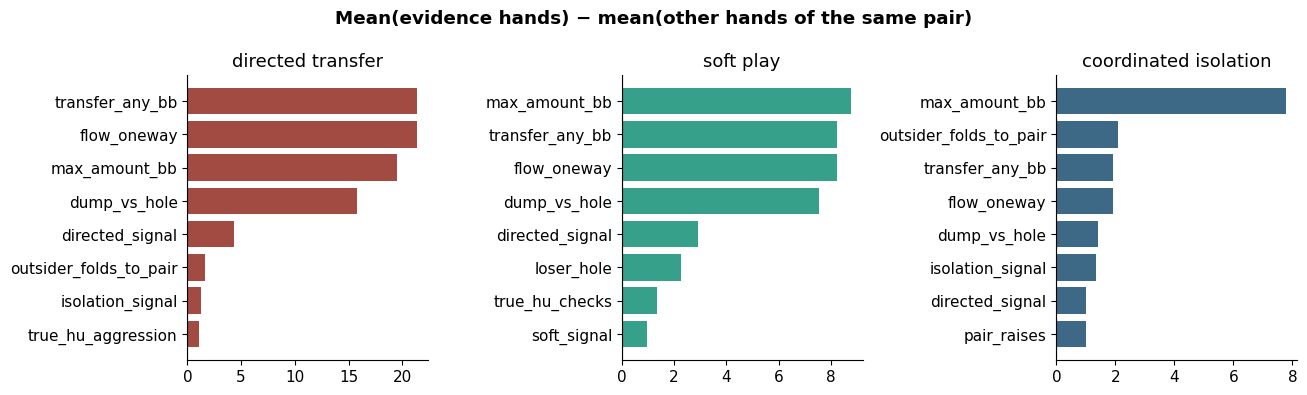

In [10]:
def evidence_lift_eda(prep_name: str = "prepared_pu24k"):
    if not DATA_OK:
        print("Need competition data.")
        return
    prep = OUTPUT_DIR / prep_name
    hand_path = prep / "dev_hand_features.parquet"
    if not hand_path.exists():
        print(f"No {hand_path} yet. Run the pipeline once.")
        return

    labels = pl.read_csv(DATA_DIR / "development_labels.csv")
    evidence = pl.read_csv(DATA_DIR / "development_evidence.csv").select(["pair_id", "hand_id"]).unique()
    positives = labels.filter(pl.col("behavior_family").is_in(BEHAVIORS)).select(["pair_id", "behavior_family"])
    keys = [
        c for c in [
            "directed_signal", "soft_signal", "isolation_signal", "transfer_any_bb",
            "flow_oneway", "dump_vs_hole", "true_hu_checks", "true_hu_aggression",
            "outsider_folds_to_pair", "partner_folds_to_pair", "pair_raises",
            "both_showdown", "loser_hole", "max_amount_bb",
        ]
        if True
    ]
    hands = (
        pl.scan_parquet(hand_path)
        .join(positives.lazy(), on="pair_id")
        .join(evidence.lazy().with_columns(pl.lit(1).alias("is_evidence")), on=["pair_id", "hand_id"], how="left")
        .with_columns(pl.col("is_evidence").fill_null(0).cast(pl.Int8))
        .collect()
    )
    keys = [c for c in keys if c in hands.columns]
    print("Positive pair-hands", f"{hands.height:,}", "| evidence", int(hands["is_evidence"].sum()))

    fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), sharey=False)
    for ax, family, color in zip(axes, BEHAVIORS, [ROSE, TEAL, NAVY]):
        sub = hands.filter(pl.col("behavior_family") == family)
        rows = []
        for c in keys:
            ev = float(sub.filter(pl.col("is_evidence") == 1)[c].mean())
            ot = float(sub.filter(pl.col("is_evidence") == 0)[c].mean())
            rows.append((c, ev - ot))
        rows.sort(key=lambda r: abs(r[1]), reverse=True)
        top = rows[:8][::-1]
        ax.barh([r[0] for r in top], [r[1] for r in top], color=color, alpha=0.85)
        ax.axvline(0, color="#333", lw=0.8)
        ax.set_title(family.replace("_", " "))
    fig.suptitle("Mean(evidence hands) − mean(other hands of the same pair)", fontweight="bold")
    fig.tight_layout()
    plt.show()


evidence_lift_eda()


<a id="9"></a>
## 9. What is still on the table

1. **Street sequences** from `actions.street` — river HU check-check; preflop squeeze (pair raise/3bet, outsider folds) then postflop check-down; loser all-in with a weak hole.
2. **Position** (`seat_no`) — isolation and dumps are not seat-symmetric.
3. **Cross-phase history** — the same 30-player pool persists; eval currently ignores development hands of that pair (train must time-split).
4. **Cliques** — 693 colluders / 372 pairs.

Not worth it until those exist: extra PU, rate surgery, LightGBM, transformers on full action sequences, `players.parquet` as an identity feature.

---

### Reproducibility

- CPU, no GPU. `tree_method=hist`. Seed 42.
- Cache: `/kaggle/working/prepared_pu24k`.
- Companion source: `poker_kaggle.py` (this notebook loads it).
- Best public configuration: **24k PU, partner-vs-field, blend risk, 5% family slice**, not the 2% elbow.

If you use this, change **one** of {sampling, pair features, evidence features} per submit. PU-stress OOF is the only in-notebook number that has tracked LB; labeled AP will stay ~0.97 either way.
